## Theoretical Questions

### 1. What is a Support Vector Machine (SVM) ?

A Support Vector Machine (SVM) is a powerful and versatile supervised machine learning algorithm used for both classification and regression tasks. However, it is primarily used for classification problems.

The core idea behind SVMs is to find the optimal hyperplane that best separates the data points into different classes in a high-dimensional space. The 'optimal' hyperplane is defined as the one with the largest margin between the nearest training data points of any class. These nearest data points are called 'support vectors'.

Key characteristics of SVMs include:

*   **Hyperplane:** A decision boundary that separates data points of different classes.
*   **Margin:** The distance between the hyperplane and the nearest data point from either class (the support vectors). A larger margin generally leads to better generalization performance.
*   **Support Vectors:** The data points that lie closest to the hyperplane and are critical in defining its position and orientation.
*   **Kernel Trick:** For non-linearly separable data, SVMs use a 'kernel trick' to map the data into a higher-dimensional feature space where it can be linearly separated. Common kernel functions include linear, polynomial, radial basis function (RBF), and sigmoid.

### 2. What is the difference between Hard Margin and Soft Margin SVM ?

The difference between Hard Margin and Soft Margin SVM lies in how they handle misclassified data points and the separability of the data:

**Hard Margin SVM:**

*   **Assumptions:** Assumes that the data is perfectly linearly separable, meaning there is a clear hyperplane that can divide the two classes without any misclassifications.
*   **Goal:** To find a hyperplane that maximizes the margin between the two classes, with the strict constraint that all data points must be correctly classified and lie on the correct side of the margin.
*   **Robustness:** Highly sensitive to outliers. If even one data point is an outlier and lies on the wrong side of the optimal hyperplane, a hard margin SVM will either fail to find a separating hyperplane or will find a hyperplane that is heavily influenced by that outlier, leading to poor generalization.
*   **Use Case:** Best suited for clean, perfectly separable datasets where misclassifications are not tolerated.

**Soft Margin SVM:**

*   **Assumptions:** Acknowledges that real-world data is often not perfectly linearly separable and may contain noise or overlapping classes.
*   **Goal:** To find a hyperplane that maximizes the margin while allowing for some misclassifications. It introduces a 'slack variable' (ξ, pronounced 'xi') for each data point that allows it to violate the margin constraint to some extent. A penalty parameter (C) controls the trade-off between maximizing the margin and minimizing the classification errors.
*   **Robustness:** More robust to outliers and noisy data. By allowing some misclassifications, it can find a more generalizable hyperplane that isn't overly sensitive to individual problematic data points.
*   **Use Case:** More commonly used in practical applications with real-world, noisy, or non-linearly separable datasets.

In essence, a Hard Margin SVM seeks a perfect separation, while a Soft Margin SVM seeks a balance between achieving a wide margin and tolerating some errors to improve generalization.

### 3. What is the mathematical intuition behind SVM ?

The mathematical intuition behind SVM revolves around finding an optimal hyperplane that best separates data points belonging to different classes. This is achieved by maximizing the margin between the hyperplane and the closest data points from each class, known as support vectors.

Here’s a breakdown of the key mathematical concepts:

1.  **Representing the Hyperplane:** A hyperplane in a $d$-dimensional space can be represented by the equation $w \cdot x + b = 0$, where:
    *   $w$ is a $d$-dimensional normal vector perpendicular to the hyperplane.
    *   $x$ is a point in $d$-dimensional space.
    *   $b$ is the bias (or intercept) term.

2.  **Classification Rule:** For a given data point $x_i$, the classification is determined by the sign of $w \cdot x_i + b$. If $w \cdot x_i + b > 0$, it belongs to one class (e.g., +1), and if $w \cdot x_i + b < 0$, it belongs to another class (e.g., -1).

3.  **Margin Maximization (Hard Margin SVM):** The goal is to find a hyperplane such that all data points are correctly classified and the distance between the hyperplane and the closest data points (support vectors) is maximized. The distance of a point $x_i$ to the hyperplane is given by $\frac{|w \cdot x_i + b|}{||w||}$.

    To simplify, we can set the functional margin (not geometric margin) for the support vectors to 1, meaning:
    *   $w \cdot x_i + b \ge 1$ for positive class ($y_i = +1$)
    *   $w \cdot x_i + b \le -1$ for negative class ($y_i = -1$)
    These can be combined as $y_i(w \cdot x_i + b) \ge 1$ for all data points $i$.

    The geometric margin is then $\frac{2}{||w||}$. Maximizing this margin is equivalent to minimizing $||w||^2$ (or $\frac{1}{2}||w||^2$ for mathematical convenience), subject to the constraint $y_i(w \cdot x_i + b) \ge 1$.

4.  **Lagrangian Formulation:** This constrained optimization problem is typically solved using Lagrangian multipliers. The Lagrangian function is formulated as:
    $L(w, b, \alpha) = \frac{1}{2}||w||^2 - \sum_{i=1}^N \alpha_i [y_i(w \cdot x_i + b) - 1]$
    where $\alpha_i$ are the Lagrange multipliers. By taking partial derivatives with respect to $w$ and $b$ and setting them to zero, we can find the optimal $w$ and $b$. This leads to the **dual problem**, which is often easier to solve and reveals that $w$ is a linear combination of the support vectors:
    $w = \sum_{i=1}^N \alpha_i y_i x_i$
    Only the $\alpha_i$ corresponding to support vectors will be non-zero.

5.  **Soft Margin SVM (Handling Non-Separable Data):** In real-world scenarios, data is rarely perfectly linearly separable. Soft Margin SVM introduces **slack variables** $\xi_i \ge 0$ (xi) to allow for some misclassification or points to be within the margin. The constraints become:
    *   $y_i(w \cdot x_i + b) \ge 1 - \xi_i$
    *   $\xi_i \ge 0$

    The objective function is modified to include a penalty for these slack violations:
    Minimize $\frac{1}{2}||w||^2 + C \sum_{i=1}^N \xi_i$
    where $C > 0$ is a regularization parameter that controls the trade-off between maximizing the margin and minimizing the classification error. A large $C$ means a higher penalty for misclassifications, leading to a smaller margin (closer to hard margin). A small $C$ allows for more misclassifications, leading to a wider margin.

6.  **Kernel Trick:** For non-linearly separable data, SVM employs the 'kernel trick'. Instead of explicitly mapping data to a higher-dimensional space (which can be computationally expensive), a **kernel function** $K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$ is used. This function calculates the dot product of the data points in the higher-dimensional feature space $\phi(x)$ without actually computing $\phi(x)$. Common kernels include polynomial, Gaussian (RBF), and sigmoid. The dual problem then uses $K(x_i, x_j)$ instead of $x_i \cdot x_j$.

In essence, SVM's mathematical intuition is about finding the widest possible 'road' (margin) between different classes, and then adapting that road to handle real-world complexities like overlapping data (soft margin) and non-linear relationships (kernel trick).

### 4. What is the role of Lagrange Multipliers in SVM ?

Lagrange Multipliers play a crucial role in Support Vector Machines (SVMs) by providing a powerful mathematical framework to solve the constrained optimization problem at the heart of SVMs. They allow us to transform the original, difficult-to-solve primal problem into an easier-to-handle dual problem.

Here's a breakdown of their role:

1.  **Solving Constrained Optimization:** The fundamental goal of SVM is to maximize the margin between the separating hyperplane and the support vectors, subject to the constraint that all data points are correctly classified (or, in the case of Soft Margin SVM, classified with an acceptable error). Lagrange Multipliers are a standard technique for finding the maxima or minima of a function subject to equality or inequality constraints.

2.  **Formulating the Lagrangian:** For a Hard Margin SVM, the objective is to minimize $\frac{1}{2}||w||^2$ subject to the constraints $y_i(w \cdot x_i + b) \ge 1$ for all data points $i$. We introduce non-negative Lagrange multipliers $\alpha_i$ for each constraint, forming the Lagrangian function:
    $L(w, b, \alpha) = \frac{1}{2}||w||^2 - \sum_{i=1}^N \alpha_i [y_i(w \cdot x_i + b) - 1]$
    The goal then becomes to find the saddle point of this Lagrangian (minimize with respect to $w, b$ and maximize with respect to $\alpha$).

3.  **Deriving the Dual Problem:** By setting the partial derivatives of the Lagrangian with respect to $w$ and $b$ to zero, we obtain conditions that allow us to express $w$ and $b$ in terms of the training data and the Lagrange multipliers $\alpha_i$. Substituting these back into the Lagrangian leads to the **dual problem**. The dual problem is often preferred because:
    *   It's a convex quadratic programming problem, for which efficient solvers exist.
    *   It elegantly incorporates the **kernel trick**, as the data points only appear as dot products ($x_i \cdot x_j$), which can be replaced by kernel functions $K(x_i, x_j)$.

4.  **Identifying Support Vectors:** A critical aspect is that many of the Lagrange multipliers $\alpha_i$ will be zero. The data points $x_i$ for which $\alpha_i > 0$ are precisely the **support vectors**. These are the points that lie closest to the hyperplane (or within the margin in Soft Margin SVM) and are directly involved in defining the hyperplane. Data points not chosen as support vectors have no influence on the final hyperplane.

5.  **Handling Soft Margin SVM:** For Soft Margin SVM, slack variables $\xi_i$ are introduced to allow for misclassifications. The constraints become $y_i(w \cdot x_i + b) \ge 1 - \xi_i$, and the objective function includes a penalty term $C \sum \xi_i$. Lagrange multipliers are similarly used to convert this into a dual problem, with the additional constraint $0 \le \alpha_i \le C$.

In summary, Lagrange Multipliers transform the SVM optimization problem into a more tractable form, facilitate the use of the kernel trick, and inherently identify the crucial data points (support vectors) that define the optimal separating hyperplane.

### 5. What are Support Vectors in SVM ?

In the context of Support Vector Machines (SVMs), Support Vectors are the data points that lie closest to the decision boundary (hyperplane) and are most influential in defining its position and orientation. They are the critical elements that 'support' the hyperplane.

Here’s a more detailed breakdown:

*   **Definition:** Support Vectors are the training data points that, if removed, would change the position of the hyperplane. They are the data points that satisfy the condition $y_i(w \cdot x_i + b) = 1$ in a Hard Margin SVM, meaning they lie exactly on the margin boundaries.
*   **Role in Margin Maximization:** SVM's objective is to maximize the margin between the separating hyperplane and the closest data points of each class. These closest data points are precisely the support vectors. Therefore, the hyperplane is entirely determined by these few, critical data points.
*   **Sparsity:** A key advantage of SVMs is that the model only depends on the support vectors, not on all the training data points. This leads to a sparse solution, meaning that most of the Lagrange multipliers ($\alpha_i$) in the dual problem will be zero for non-support vectors. Only the $\alpha_i$ corresponding to support vectors will be greater than zero.
*   **Robustness (Soft Margin SVM):** In Soft Margin SVM, support vectors can also include points that are misclassified or lie within the margin. These points have a slack variable $\xi_i > 0$ and their corresponding Lagrange multiplier $\alpha_i$ will be positive, potentially up to the regularization parameter $C$ (i.e., $0 < \alpha_i \le C$). Points with $\alpha_i = C$ are often considered 'margin violators' or points that are heavily penalized.
*   **Efficiency:** Because the decision boundary is only determined by a subset of the training data (the support vectors), SVMs can be computationally efficient, especially in high-dimensional spaces or with large datasets, as long as the number of support vectors remains manageable.

### 6. What is a Support Vector Classifier (SVC) ?

A Support Vector Classifier (SVC) is the most common application of Support Vector Machines (SVMs), specifically tailored for classification tasks. While SVM is a broader concept that can handle both classification and regression, SVC refers to the implementation used when the output variable is categorical (i.e., discrete classes).

Essentially, SVC takes the core principles of SVM (finding an optimal hyperplane with maximal margin) and applies them to classify data points into one of several predefined classes. It aims to find the best decision boundary that separates data points of different classes in a high-dimensional feature space.

Key characteristics and concepts relevant to SVC:

*   **Hyperplane:** The decision boundary that separates the classes. In a 2D space, it's a line; in 3D, a plane; and in higher dimensions, a hyperplane.
*   **Margin Maximization:** SVC works by maximizing the distance between the hyperplane and the nearest data points of each class. These nearest points are called **support vectors**, and the region between the parallel hyperplanes passing through these support vectors is the margin.
*   **Soft Margin Classification:** Most practical SVC implementations use a 'soft margin' approach. This means they allow for some misclassification or data points to fall within the margin. This is controlled by a regularization parameter `C`. A smaller `C` allows for a wider margin and more misclassifications (more regularization, simpler model), while a larger `C` enforces a stricter separation (narrower margin, less regularization, more complex model).
*   **Kernel Trick:** For non-linearly separable data, SVC employs the 'kernel trick'. This involves using a kernel function (e.g., Radial Basis Function/RBF, polynomial, sigmoid) to implicitly map the input data into a higher-dimensional feature space where it may become linearly separable. This avoids the computational cost of explicitly calculating the coordinates in the higher dimension.
*   **Output:** For a given input, an SVC model will predict the class label (e.g., 0 or 1, or multiple class labels). Some SVC implementations can also provide a probability estimate for each class.

In summary, an SVC is the classification variant of SVM, designed to draw optimal decision boundaries to separate different classes of data, often leveraging soft margins and the kernel trick to handle real-world complexities.

### 7. What is a Support Vector Regressor (SVR) ?

A Support Vector Regressor (SVR) is a variant of Support Vector Machines (SVMs) specifically adapted for regression tasks, rather than classification. While SVMs aim to find a hyperplane that separates data into distinct classes, SVRs aim to find a function that best fits the data points, minimizing the error between the predicted and actual values.

Key concepts and differences from SVC:

*   **Goal:** Instead of finding a decision boundary, SVR seeks to find a hyperplane that best approximates the relationship between input features and a continuous output variable. It tries to fit as many data points as possible within a certain margin of tolerance.
*   **Epsilon-Insensitive Tube (ε-tube):** Unlike SVC, which has a margin around the hyperplane that separates classes, SVR introduces an 'epsilon-insensitive tube' (ε-tube) around the regression line. The goal is to find a hyperplane such that as many data points as possible fall within this tube, and only points outside the tube contribute to the penalty (error).
*   **Margin of Tolerance (ε):** This parameter defines the width of the ε-tube. Data points within this tube are not penalized, meaning their error is considered zero. This makes SVR robust to noise and outliers within the epsilon margin.
*   **Slack Variables (ξ and ξ*):** Similar to Soft Margin SVM, SVR also uses slack variables to allow for some errors. Two slack variables, $\xi_i$ (xi) and $\xi_i^*$ (xi-star), are used for each data point to account for points lying above and below the ε-tube, respectively.
*   **Regularization Parameter (C):** As in SVC, `C` controls the trade-off between the flatness of the function (minimizing $||w||^2$) and the amount of error (minimizing the sum of slack variables). A smaller `C` emphasizes a flatter function, while a larger `C` aims for a more accurate fit to the training data.
*   **Support Vectors:** In SVR, support vectors are the data points that lie outside or on the boundary of the ε-tube. These are the points that influence the shape of the regression function.
*   **Kernel Trick:** SVR also uses the kernel trick to handle non-linear regression problems by mapping the input data into a higher-dimensional feature space where a linear regression can be performed.

In essence, SVR finds a function that has at most ε deviation from the actual target values for all training data, while being as flat as possible (i.e., minimizing the coefficients $w$). It's particularly useful for problems where you need to model relationships with a tolerance for minor inaccuracies, making it less sensitive to small variations in the data.

### 8. What is the Kernel Trick in SVM ?

The Kernel Trick is a crucial technique used in Support Vector Machines (SVMs) to handle non-linearly separable data without explicitly transforming the data into a higher-dimensional space. This makes SVMs powerful for a wide range of complex datasets.

Here's a breakdown of the Kernel Trick:

1.  **The Problem with Non-Linear Data:** Many real-world datasets are not linearly separable in their original input space. This means that a single straight line (or hyperplane in higher dimensions) cannot perfectly separate the different classes.

2.  **Mapping to a Higher-Dimensional Space:** A common approach to make non-linear data linearly separable is to map the data from the original low-dimensional input space to a higher-dimensional feature space. In this new space, the data might become linearly separable, allowing an SVM to find a hyperplane.

3.  **The Computational Challenge:** Explicitly calculating the coordinates of all data points in a very high (or even infinite) dimensional feature space can be computationally prohibitive, both in terms of time and memory. This is where the Kernel Trick comes in.

4.  **The Trick: Kernel Functions:** Instead of explicitly performing the mapping $\phi(x)$ and then computing the dot product $\phi(x_i) \cdot \phi(x_j)$ in the high-dimensional space, the Kernel Trick uses a **kernel function**, denoted as $K(x_i, x_j)$, that directly computes this dot product in the original low-dimensional space.

    Mathematically, $K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)$. The kernel function allows us to operate in the implicit high-dimensional feature space without ever needing to know the coordinates of the data in that space.

5.  **Common Kernel Functions:**
    *   **Linear Kernel:** $K(x_i, x_j) = x_i \cdot x_j$ (Equivalent to a standard linear SVM without transformation).
    *   **Polynomial Kernel:** $K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d$, where $\gamma$, $r$, and $d$ are parameters.
    *   **Radial Basis Function (RBF) or Gaussian Kernel:** $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$, where $\gamma$ is a parameter. This is one of the most widely used kernels and can map data into an infinite-dimensional space.
    *   **Sigmoid Kernel:** $K(x_i, x_j) = \tanh(\gamma x_i \cdot x_j + r)$, where $\gamma$ and $r$ are parameters.

6.  **Benefits of the Kernel Trick:**
    *   **Handles Non-Linearity:** Allows SVMs to model complex, non-linear decision boundaries.
    *   **Computational Efficiency:** Avoids the expensive explicit computation of high-dimensional feature vectors.
    *   **Mathematical Elegance:** Integrates seamlessly into the dual formulation of the SVM optimization problem.

In essence, the Kernel Trick is a clever mathematical shortcut that enables SVMs to effectively classify or regress non-linearly separable data by implicitly working in a higher-dimensional feature space, making them highly versatile and powerful machine learning models.

### 9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel .

Each kernel function transforms the data into a higher-dimensional feature space, allowing SVMs to find a linear decision boundary even for non-linearly separable data. Here's a comparison of Linear, Polynomial, and Radial Basis Function (RBF) kernels:

**1. Linear Kernel:**

*   **Formula:** $K(x_i, x_j) = x_i \cdot x_j$
*   **Concept:** This is the simplest kernel, essentially performing a dot product of the input features. It does not map the data to a higher-dimensional space but rather works directly in the original feature space. It's equivalent to standard linear SVM.
*   **Use Cases:** Best suited for linearly separable data or when the number of features is very large compared to the number of samples. It's generally fast to train and interpret.
*   **Advantages:** Computationally efficient, easy to interpret (the decision boundary is a straight line/plane), performs well with high-dimensional sparse data (e.g., text classification).
*   **Disadvantages:** Cannot handle non-linearly separable data effectively.
*   **Parameters:** None (or `gamma='scale'` in some implementations, which scales the input data before the dot product, but doesn't change the linear nature).

**2. Polynomial Kernel:**

*   **Formula:** $K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d$
*   **Concept:** Maps the data into a higher-dimensional space by considering polynomial combinations of the original features. The degree `d` of the polynomial determines the complexity of the decision boundary. For `d=1`, it behaves like a linear kernel.
*   **Use Cases:** Suitable for non-linearly separable data where a curved or polynomial decision boundary is appropriate. Can capture more complex relationships than a linear kernel.
*   **Advantages:** Can model non-linear relationships. The degree of the polynomial offers flexibility.
*   **Disadvantages:** Can be prone to overfitting, especially with high degrees. Computationally more expensive than the linear kernel. The parameters `gamma` and `r` can be tricky to tune.
*   **Parameters:**
    *   `d` (degree): The degree of the polynomial. Higher degrees lead to more complex models.
    *   `gamma` (coef0): A coefficient for the dot product. Controls the influence of individual training samples.
    *   `r` (coef0): An independent term in the polynomial function. Influences the model's behavior.

**3. Radial Basis Function (RBF) Kernel (Gaussian Kernel):**

*   **Formula:** $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$
*   **Concept:** Maps data into an infinite-dimensional space. It essentially measures the similarity between two data points. The closer two points are in the original space, the higher their similarity (kernel value). It creates a decision boundary that can be very complex and non-linear, resembling a smooth curve or surface.
*   **Use Cases:** Widely used and often the default choice for non-linearly separable data due to its flexibility and ability to capture complex patterns. It works well when there's no prior knowledge about the data distribution.
*   **Advantages:** Very powerful and flexible, can handle highly non-linear relationships. Has fewer hyperparameters to tune compared to the polynomial kernel (primarily `gamma` and `C`).
*   **Disadvantages:** Computationally more expensive than the linear kernel, especially with large datasets. Prone to overfitting if `gamma` is too high. Can be difficult to interpret the decision boundary directly in the original feature space.
*   **Parameters:**
    *   `gamma`: Controls the influence of a single training example. A small `gamma` means a large radius of influence, leading to a smoother decision boundary (underfitting). A large `gamma` means a small radius of influence, leading to a more complex boundary (overfitting).

**Summary Table:**

| Feature           | Linear Kernel                 | Polynomial Kernel             | RBF Kernel (Gaussian)         |
| :---------------- | :---------------------------- | :---------------------------- | :---------------------------- |
| **Equation**      | $x_i \cdot x_j$               | $(\gamma x_i \cdot x_j + r)^d$ | $\exp(-\gamma ||x_i - x_j||^2)$ |
| **Decision Bnd.** | Linear                        | Non-linear (curved)           | Highly Non-linear (complex)   |
| **Complexity**    | Low                           | Medium                        | High                          |
| **Overfitting**   | Less prone                    | Moderate to High              | Moderate to High              |
| **Interpret.**    | Easy                          | Moderate                      | Difficult                     |
| **Performance**   | Good for linear/high-dim data | Good for non-linear data      | Generally good, flexible      |
| **Parameters**    | None                          | `d`, `gamma`, `r`             | `gamma`                       |

Choosing the right kernel depends on the nature of your data and the problem you're trying to solve. The RBF kernel is often a good starting point, and its performance can be optimized by tuning `gamma` and the regularization parameter `C`.

### 10. What is the effect of the C parameter in SVM ?

The `C` parameter in Support Vector Machines (SVM) is a regularization parameter that controls the trade-off between achieving a wide margin and minimizing classification errors. It's a crucial hyperparameter, especially in Soft Margin SVM, which allows for some misclassifications.

Here's a breakdown of its effect:

1.  **Definition of `C`:** The `C` parameter is a positive value that penalizes misclassified training examples. A smaller `C` value creates a larger margin but allows more misclassifications (more regularization). A larger `C` value creates a smaller margin but aims for fewer misclassifications (less regularization).

2.  **Small `C` (High Regularization):**
    *   **Wider Margin:** A small `C` means that the penalty for misclassifications is low. The SVM will prioritize finding a hyperplane with a larger margin, even if it means misclassifying more training points.
    *   **Smoother Decision Boundary:** The model is more tolerant of errors and outliers. This leads to a simpler, smoother decision boundary, which can help in generalizing to unseen data.
    *   **Risk of Underfitting:** If `C` is too small, the model might be too regularized and fail to capture the underlying patterns in the data, leading to underfitting.

3.  **Large `C` (Low Regularization):**
    *   **Narrower Margin:** A large `C` means that the penalty for misclassifications is high. The SVM will try to correctly classify as many training points as possible, even if it results in a narrower margin.
    *   **Complex Decision Boundary:** The model becomes less tolerant of errors and outliers, trying to fit the training data as perfectly as possible. This can lead to a more complex, jagged decision boundary.
    *   **Risk of Overfitting:** If `C` is too large, the model might fit the noise in the training data too closely, leading to poor generalization performance on new data (overfitting).

4.  **Balance Between Bias and Variance:** The `C` parameter essentially controls the bias-variance trade-off:
    *   Small `C`: Higher bias, lower variance (simpler model, potentially underfits).
    *   Large `C`: Lower bias, higher variance (complex model, potentially overfits).

5.  **Impact on Support Vectors:**
    *   Small `C`: Fewer support vectors, as more points are allowed to be within the margin or misclassified.
    *   Large `C`: More support vectors, as the model tries to accommodate almost all training points, making more of them critical for defining the boundary.

In practice, `C` is a hyperparameter that needs to be tuned using techniques like cross-validation to find the optimal balance for a given dataset.

### 11. What is the role of the Gamma parameter in RBF Kernel SVM ?

The `gamma` parameter is a hyperparameter specifically associated with kernel functions like the Radial Basis Function (RBF) kernel in Support Vector Machines (SVM). It defines how much influence a single training example has, or in other words, how far the influence of a single training example reaches.

Here's a breakdown of its role:

1.  **Defining the 'Reach' or 'Influence' of a Single Training Example:**
    *   In the RBF kernel formula, $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$, the `gamma` parameter appears in the exponent. It effectively controls the shape of the 'bell curve' that is centered on each support vector.
    *   A small `gamma` value means a large radius of influence. This implies that the 'bell curve' is wide and smooth, and data points far away from the decision boundary (or support vectors) still have a considerable influence on the decision function.
    *   A large `gamma` value means a small radius of influence. This implies that the 'bell curve' is narrow and sharp, and only data points very close to the decision boundary (or support vectors) have a significant influence on the decision function.

2.  **Impact on Decision Boundary Complexity:**
    *   **Small `gamma` (Low Complexity / Underfitting Risk):**
        *   A small `gamma` leads to a smoother, simpler decision boundary. The model tries to capture general patterns and ignores individual data points' specific details.
        *   This can result in a model with high bias and low variance, potentially leading to **underfitting** if the boundary is too generalized and fails to capture the underlying structure of the data.
    *   **Large `gamma` (High Complexity / Overfitting Risk):**
        *   A large `gamma` leads to a more complex and intricate decision boundary. The model tries to fit every training data point as closely as possible, even noise.
        *   This can result in a model with low bias and high variance, potentially leading to **overfitting** as the model learns the training data too well, including its noise, and performs poorly on unseen data.

3.  **Relationship with `C` Parameter:** `gamma` and the regularization parameter `C` are often tuned together. While `gamma` controls the *shape* of the decision region, `C` controls the *tolerance for misclassification*.
    *   A high `gamma` (complex model) with a high `C` (low tolerance for errors) can easily lead to severe overfitting.
    *   A low `gamma` (simple model) with a low `C` (high tolerance for errors) might lead to underfitting.

In practice, tuning `gamma` is crucial for optimizing the performance of RBF Kernel SVM models. It's often done through techniques like grid search or random search with cross-validation to find the optimal balance between model complexity and generalization ability.

### 12. What is the Naïve Bayes classifier, and why is it called "Naïve" ?

The Naïve Bayes classifier is a probabilistic machine learning algorithm that is based on Bayes' theorem. It is primarily used for classification tasks.

**What is a Naïve Bayes classifier?**

At its core, a Naïve Bayes classifier works by calculating the probability of a given data point belonging to a certain class, given its features. It assumes that the presence of a particular feature in a class is independent of the presence of any other feature. Even if these features depend on each other or upon the existence of the other features, a Naïve Bayes classifier considers all of these properties to independently contribute to the probability.

It works as follows:
1.  **Calculate prior probabilities:** Determine the probability of each class occurring in the dataset (e.g., P(spam), P(not spam)).
2.  **Calculate likelihood probabilities:** For each feature, calculate the probability of that feature occurring given each class (e.g., P('money' | spam), P('money' | not spam)).
3.  **Apply Bayes' Theorem:** Combine prior and likelihood probabilities to calculate the posterior probability of a data point belonging to a class given its features: P(Class | Features) = P(Features | Class) * P(Class) / P(Features).
4.  **Classification:** The data point is assigned to the class with the highest posterior probability.

Common applications include spam filtering, sentiment analysis, and document classification.

**Why is it called "Naïve"?**

The "Naïve" part of the name comes from its fundamental assumption: the **strong (or 'naïve') assumption of conditional independence** between features given the class label. In simpler terms, it assumes that:

*   **Each feature contributes independently to the probability of a class.** For example, when classifying an email as spam, a Naïve Bayes classifier assumes that the probability of the word "money" appearing in a spam email is independent of the probability of the word "viagra" appearing in the same spam email, even though in reality, these words might often co-occur in spam.
*   **No correlation between features.** It ignores any potential relationships or dependencies between the input features.

This assumption is often violated in real-world datasets, where features are rarely truly independent. For instance, in an image, the presence of an 'eye' is highly dependent on the presence of a 'nose' nearby if you're trying to classify a 'face'. However, despite this oversimplified assumption, Naïve Bayes classifiers often perform surprisingly well in practice, especially with high-dimensional data, due to their simplicity, speed, and robustness to irrelevant features.

### 13. What is Bayes’ Theorem ?

Bayes' Theorem is a fundamental concept in probability theory that describes how to update the probability of a hypothesis as more evidence or information becomes available. It's particularly important in machine learning for probabilistic models, including the Naïve Bayes classifier.

Mathematically, Bayes' Theorem is expressed as:

$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$

Where:

*   **$P(A|B)$ (Posterior Probability):** This is the probability of hypothesis A being true, given that event B has occurred. This is what we want to find – the updated probability of A after considering the evidence B.
*   **$P(B|A)$ (Likelihood):** This is the probability of observing event B, given that hypothesis A is true. It measures how likely the evidence B is under the assumption that A is true.
*   **$P(A)$ (Prior Probability):** This is the initial probability of hypothesis A being true before any evidence B is observed. It represents our prior belief or knowledge about A.
*   **$P(B)$ (Marginal Likelihood or Evidence):** This is the total probability of observing event B, regardless of whether hypothesis A is true or not. It acts as a normalizing constant to ensure that the posterior probability is a valid probability (sums to 1).

In simpler terms, Bayes' Theorem provides a way to calculate the "probability of a cause, given an effect." For example:

*   **Hypothesis (A):** A patient has a specific disease.
*   **Evidence (B):** A medical test result for that disease is positive.

Bayes' Theorem would allow us to calculate the probability that the patient actually has the disease, given a positive test result, by considering:

*   The overall prevalence of the disease in the population ($P(A)$).
*   The accuracy of the test (how often it's positive when the person has the disease, $P(B|A)$).
*   The rate of false positives (how often the test is positive when the person does not have the disease, which contributes to $P(B)$).

It's a powerful tool for probabilistic reasoning, allowing us to quantify how new information should rationally change our beliefs about the likelihood of various outcomes.

### 14. Explain the differences between Gaussian Naïve Bayes, Multinomial Naïve Bayes, and Bernoulli Naïve Bayes ?

While all Naïve Bayes classifiers are based on Bayes' Theorem and the assumption of feature independence, they differ in the way they model the likelihood of features, specifically depending on the type of input data they expect.

Here's a breakdown of the main differences:

**1. Gaussian Naïve Bayes:**

*   **Assumes:** That the features follow a Gaussian (normal) distribution. This means that continuous numerical features are handled by assuming they are sampled from a Gaussian distribution.
*   **Likelihood Calculation:** It calculates the mean and standard deviation for each feature within each class. The probability of a feature value given a class is then determined using the probability density function of the Gaussian distribution.
*   **Use Cases:** Best suited for continuous-valued features that are normally distributed. If features are not normally distributed, transformations might be needed.
*   **Example:** Classifying an email as spam based on the *length* of the email, where email length is a continuous numerical feature.

**2. Multinomial Naïve Bayes:**

*   **Assumes:** That the features represent the frequencies with which certain events have been observed. It is typically used for discrete counts, such as word counts in text classification.
*   **Likelihood Calculation:** The probabilities are calculated based on the frequency of each feature (e.g., word) occurring in a document, given its class. It models the probability of observing a particular count for a feature.
*   **Use Cases:** Widely used in text classification (e.g., spam filtering, sentiment analysis) where features are typically word counts or term frequencies.
*   **Example:** Classifying a document as

### 15. When should you use Gaussian Naïve Bayes over other variants ?

You should use Gaussian Naïve Bayes primarily when your features are continuous and are assumed to follow a Gaussian (normal) distribution. Here's a breakdown of situations where it's the most appropriate choice:

1.  **Continuous Numerical Features:** Gaussian Naïve Bayes is designed for data where features can take on any real value within a range (e.g., height, weight, temperature, sensor readings, length of an email, intensity of a pixel). Unlike Multinomial Naïve Bayes (which handles discrete counts) or Bernoulli Naïve Bayes (which handles binary features), it models the likelihood of these continuous values using a Gaussian probability density function.

2.  **Assumption of Normal Distribution:** The core assumption is that, within each class, the continuous features are normally distributed. If this assumption holds true, or approximately true, Gaussian Naïve Bayes can be very effective.

3.  **Small to Medium Datasets:** While Naïve Bayes classifiers are generally efficient, Gaussian Naïve Bayes can perform well on datasets of various sizes, particularly when the feature distributions within classes can be reasonably estimated.

4.  **Simplicity and Speed:** Like other Naïve Bayes variants, it's computationally very fast for both training and prediction. If you need a quick baseline model or a classifier for real-time predictions with continuous data, Gaussian Naïve Bayes is a strong candidate.

5.  **When Feature Independence is a Reasonable (or Tolerable) Assumption:** Although the 'naïve' independence assumption is rarely perfectly met in real-world continuous data, Gaussian Naïve Bayes can still perform surprisingly well in many cases, especially if the dependencies are not too strong.

6.  **As a Baseline Model:** Even if you suspect your continuous features are not perfectly Gaussian, Gaussian Naïve Bayes can serve as an excellent baseline against which more complex models can be compared. If it performs well, you might not need a more intricate model.

**Contrast with other variants:**

*   **Multinomial Naïve Bayes:** Best for discrete data representing counts or frequencies (e.g., word counts in text documents, number of events).
*   **Bernoulli Naïve Bayes:** Best for binary or boolean features (e.g., presence or absence of a word in a document, true/false flags).

In summary, choose Gaussian Naïve Bayes when your input features are continuous and you can assume (or are willing to approximate) that they follow a normal distribution within each class. If your features are counts or binary, you should opt for Multinomial or Bernoulli Naïve Bayes, respectively.

### 16. What are the key assumptions made by Naïve Bayes ?

The Naïve Bayes classifier, despite its effectiveness, relies on a few key assumptions that simplify the probability calculations. The most prominent and often criticized assumption is:

1.  **Conditional Independence of Features:** This is the 'naïve' part of the algorithm. It assumes that each feature is independent of every other feature, given the class label. In other words, the presence or absence of one feature does not affect the presence or absence of any other feature, as long as we know the class of the observation.

    *   **Example:** If you're classifying an email as spam, Naïve Bayes would assume that the probability of the word "money" appearing is independent of the word "viagra" appearing, given that the email is spam. In reality, these words might frequently co-occur in spam emails.

While this assumption is almost always false in real-world datasets, Naïve Bayes classifiers often perform surprisingly well. This is because:

*   **It's a classifier, not a probability estimator:** Even if the probability estimates are inaccurate due to the independence assumption, the classification outcome (which class has the highest probability) can still be correct.
*   **Robustness to irrelevant features:** Features that are truly independent or conditionally independent do not harm the model much, and it can handle a large number of features effectively.
*   **Simplicity and speed:** The strong independence assumption makes calculations very efficient, allowing it to be trained quickly on large datasets.

Other implicit or explicit assumptions depending on the specific variant (Gaussian, Multinomial, Bernoulli) include:

2.  **Feature Distribution (for Gaussian Naïve Bayes):** Assumes that continuous features follow a Gaussian (normal) distribution within each class.
3.  **Discrete Counts/Frequencies (for Multinomial Naïve Bayes):** Assumes features represent counts or frequencies (e.g., word occurrences), following a multinomial distribution.
4.  **Binary Features (for Bernoulli Naïve Bayes):** Assumes features are binary (0 or 1), indicating presence or absence, following a Bernoulli distribution.
5.  **Data Generation Process:** It implicitly assumes that the data is generated from a probabilistic process where features are drawn independently given the class.

Understanding these assumptions is crucial for knowing the strengths and limitations of Naïve Bayes and when it might be an appropriate model to use.

### 17. What are the advantages and disadvantages of Naïve Bayes ?

Naïve Bayes classifiers are simple yet powerful algorithms with distinct advantages and disadvantages:

**Advantages:**

1.  **Simplicity and Speed:** They are very easy and fast to implement, especially for large datasets. The training time is minimal because it only involves calculating probabilities and not complex iterative optimization.
2.  **Highly Scalable:** They scale linearly with the number of features and data points, making them suitable for large datasets and high-dimensional data (e.g., text classification with many words).
3.  **Good Performance with High-Dimensional Data:** Despite the 'naïve' independence assumption, they often perform surprisingly well in many real-world scenarios, particularly in text classification and spam filtering, where the number of features can be very high.
4.  **Handles Irrelevant Features Well:** Features that are truly independent or conditionally independent do not significantly harm the model's performance.
5.  **Handles Missing Data (Implicitly):** During probability calculation, if a feature value is missing for a given observation, that feature is simply ignored for that observation, rather than requiring explicit imputation.
6.  **Requires Less Training Data (Sometimes):** When the independence assumption holds reasonably well, Naïve Bayes can perform effectively even with relatively small training datasets compared to more complex models.
7.  **Probabilistic Predictions:** It provides probabilistic predictions, which can be useful for decision-making (e.g., how likely is this email spam?).

**Disadvantages:**

1.  **Strong Independence Assumption:** The biggest disadvantage is the 'naïve' assumption of conditional independence among features. This assumption is rarely met in real-world data, which can lead to biased probability estimates.
2.  **Zero-Frequency Problem:** If a categorical feature value does not appear in the training data for a particular class, the probability for that feature given that class will be zero. This can cause the entire posterior probability to become zero, leading to erroneous predictions. This is often handled using smoothing techniques like Laplace smoothing.
3.  **Sensitivity to Feature Engineering:** The performance can be highly dependent on how features are engineered, especially for continuous features (e.g., if using Gaussian Naïve Bayes, the assumption of normality must hold).
4.  **Cannot Learn Feature Interactions:** Due to the independence assumption, Naïve Bayes cannot capture interactions between features. For example, if two features together strongly predict an outcome but individually have weak predictive power, Naïve Bayes might miss this.
5.  **Not a Good Estimator for Probabilities:** While it's a decent classifier (i.e., it can correctly rank classes by probability), the actual probability values it outputs might be less reliable due to the strong assumptions. This is often compensated by calibrating the probabilities.

Despite its disadvantages, Naïve Bayes remains a popular choice for baseline models and for specific applications where its speed and simplicity are highly valued.

### 18. Why is Naïve Bayes a good choice for text classification ?

Naïve Bayes is often a very good choice for text classification due to several factors that align well with the nature of textual data:

1.  **High Dimensionality of Text Data:** Text data typically involves a very large number of features (e.g., thousands of unique words or n-grams in a vocabulary). Naïve Bayes models handle high-dimensional data efficiently because they only need to calculate and store the probabilities for each feature given each class. The independence assumption simplifies this significantly, avoiding the need to calculate complex covariance matrices.

2.  **Simplicity and Speed:** Training a Naïve Bayes classifier for text is computationally inexpensive and very fast. It primarily involves counting word occurrences and calculating probabilities, rather than complex iterative optimization. This makes it ideal for large text datasets and real-time classification tasks (e.g., spam filtering).

3.  **Good Performance with Limited Data (Sometimes):** While generally more complex models need a lot of data, Naïve Bayes can perform surprisingly well even with relatively small training datasets, especially if the features are somewhat independent and the signal is strong.

4.  **Robustness to Irrelevant Features:** In text, many words might be irrelevant to the classification task. Naïve Bayes is less affected by irrelevant features because if a feature's probability is roughly uniform across all classes, it won't significantly influence the posterior probabilities for any particular class.

5.  **Probabilistic Predictions:** It naturally provides probability scores for each class, which can be useful for ranking documents or setting confidence thresholds.

6.  **Interpretability (to some extent):** By examining the conditional probabilities $P(\text{word}|\text{class})$, you can get an idea of which words are most indicative of a particular class (e.g., "money" and "free" for spam). This offers some level of interpretability.

7.  **Natural Fit for Count-Based Features:** Text data is often represented using models like Bag-of-Words or TF-IDF, which result in discrete counts or frequency-based features. The Multinomial Naïve Bayes variant is perfectly suited for such representations, as it models the probability of observing word counts.

Despite the "naïve" independence assumption, which is rarely true for text (words are often dependent on preceding words), Naïve Bayes has proven to be an effective and competitive baseline for many text classification problems, including:

*   **Spam Detection:** One of its earliest and most successful applications.
*   **Sentiment Analysis:** Classifying text as positive, negative, or neutral.
*   **Document Categorization:** Assigning news articles, emails, or web pages to predefined topics.

Its combination of speed, simplicity, and reasonable accuracy makes it a go-to algorithm for initial exploration and deployment in text classification scenarios.

### 19. Compare SVM and Naïve Bayes for classification tasks .

Support Vector Machines (SVM) and Naïve Bayes are two fundamentally different yet widely used classification algorithms. Their strengths, weaknesses, and optimal use cases differ significantly due to their underlying principles.

Here's a comparison:

**1. Underlying Principle:**

*   **SVM:** Discriminative model. It aims to find an optimal decision boundary (hyperplane) that best separates the classes by maximizing the margin between the closest data points (support vectors) of different classes. It focuses on the boundary.
*   **Naïve Bayes:** Generative model. It models the probability distribution of each class and then uses Bayes' Theorem to calculate the posterior probability of a data point belonging to a particular class. It focuses on how data is generated within each class.

**2. Feature Independence Assumption:**

*   **SVM:** Does not make strong assumptions about the independence of features. It can handle correlated features well.
*   **Naïve Bayes:** Makes a very strong (naïve) assumption of conditional independence between features given the class label. This assumption is rarely true in real-world data but often works surprisingly well.

**3. Handling of Data:**

*   **SVM:** Sensitive to the scaling of features (especially with kernels like RBF). Can be computationally intensive with very large datasets, particularly during training, but prediction is fast. Handles high-dimensional data well, especially with the kernel trick.
*   **Naïve Bayes:** Not sensitive to feature scaling. Extremely fast to train and predict, even with very large and high-dimensional datasets. Good for data with many features where many are irrelevant.

**4. Decision Boundary:**

*   **SVM:** Can learn complex, non-linear decision boundaries through the use of various kernel functions (e.g., RBF, polynomial). The boundary is determined by support vectors.
*   **Naïve Bayes:** Learns a linear decision boundary (or non-linear if the probability distributions combine to form a non-linear boundary). The boundary is often simpler due to the independence assumption.

**5. Overfitting/Underfitting:**

*   **SVM:** Prone to overfitting with complex kernels (e.g., high-degree polynomial, small gamma for RBF) and high `C` values. Requires careful tuning of hyperparameters like `C` and kernel parameters (`gamma`, `degree`).
*   **Naïve Bayes:** Less prone to overfitting due to its strong assumptions and simplicity. Can sometimes underfit if the independence assumption is severely violated and the model is too simplistic for the data's complexity.

**6. Probabilistic Output:**

*   **SVM:** By default, provides class labels. Probabilistic outputs (confidence scores) can be obtained but often require additional calibration (e.g., Platt scaling) as they are not inherently well-calibrated probabilities.
*   **Naïve Bayes:** Naturally provides probabilistic outputs (posterior probabilities) that are often easier to interpret, though the actual probability values might be biased due to the independence assumption.

**7. Performance with Small Training Data:**

*   **SVM:** Generally requires a reasonable amount of data to learn effective decision boundaries, especially with complex kernels.
*   **Naïve Bayes:** Can perform surprisingly well even with relatively small training datasets if the independence assumption holds reasonably true.

**8. Outliers:**

*   **SVM:** Hard Margin SVMs are very sensitive to outliers. Soft Margin SVMs (with appropriate `C`) are more robust.
*   **Naïve Bayes:** Generally more robust to outliers as they are typically averaged out in probability calculations.

**Summary Table:**

| Feature                       | Support Vector Machine (SVM)                          | Naïve Bayes (NB)                                      |
| :---------------------------- | :---------------------------------------------------- | :---------------------------------------------------- |
| **Model Type**                | Discriminative                                        | Generative                                            |
| **Feature Assumption**        | None (handles correlated features)                    | Strong conditional independence                       |
| **Speed (Training)**          | Moderate to Slow (with complex kernels/large data)    | Very Fast                                             |
| **Speed (Prediction)**        | Fast                                                  | Very Fast                                             |
| **Data Scaling**              | Sensitive                                             | Not Sensitive                                         |
| **Decision Boundary**         | Can be complex, non-linear (kernel trick)             | Usually linear (or simple non-linear)                 |
| **Overfitting Risk**          | High (if not tuned well)                              | Low (can underfit)                                    |
| **Probabilistic Output**      | Not inherently well-calibrated (needs calibration)    | Inherently probabilistic (but values can be biased)   |
| **Small Data Performance**    | Requires more data for complex models                 | Can perform well with less data (if assumptions hold) |
| **Outlier Sensitivity**       | Hard Margin: High; Soft Margin: Moderate              | Low                                                   |
| **Common Use Cases**          | Image classification, bioinformatics, text classification (with proper feature engineering) | Text classification (spam, sentiment), document categorization, medical diagnosis |

**Conclusion:**

*   Choose **Naïve Bayes** when you have a very large, high-dimensional dataset (especially text), you need a very fast and simple baseline, or the independence assumption is plausible (or not severely violated). Its speed and simplicity make it a great first choice.
*   Choose **SVM** when you need powerful, flexible models to capture complex non-linear relationships, are concerned about generalization performance, and have a dataset where the features might be correlated. It often achieves high accuracy with well-tuned hyperparameters.

### 20. How does Laplace Smoothing help in Naïve Bayes ?

Laplace Smoothing, also known as add-one smoothing, is a technique used in Naïve Bayes classifiers (particularly Multinomial and Bernoulli variants) to address the **'zero-frequency problem'**. This problem occurs when a particular feature value (e.g., a specific word in text classification) does not appear in the training data for a given class. If this happens, the probability of that feature given the class becomes zero, and consequently, the entire posterior probability for that class becomes zero, regardless of other features. This can lead to erroneous classifications.

Here's how Laplace Smoothing helps:

1.  **Prevents Zero Probabilities:** It modifies the probability calculation by adding a small constant (usually 1, hence 'add-one') to the count of every feature for every class, and also adding `k` (the number of unique features/words in the vocabulary) to the denominator.

    *   **Original Probability Formula (for Multinomial NB):**
        $P(feature_i | Class) = \frac{\text{count}(feature_i, Class)}{\sum_{j=1}^k \text{count}(feature_j, Class)}$

    *   **Laplace Smoothed Probability Formula:**
        $P(feature_i | Class) = \frac{\text{count}(feature_i, Class) + \alpha}{\sum_{j=1}^k (\text{count}(feature_j, Class) + \alpha)} = \frac{\text{count}(feature_i, Class) + \alpha}{\sum_{j=1}^k \text{count}(feature_j, Class) + \alpha \cdot k}$
        Where:
        *   $\alpha$ is the smoothing parameter (typically 1 for Laplace smoothing).
        *   $k$ is the total number of unique features in the vocabulary (or categories for a categorical feature).

2.  **Ensures Robustness:** By adding a pseudo-count ($\alpha$) to every feature count, even features not seen in a particular class get a non-zero, albeit small, probability. This ensures that the posterior probability for a class never becomes strictly zero due to an unseen feature, making the model more robust.

3.  **Addresses Unseen Data:** In real-world applications, especially with text, it's highly likely that new documents will contain words not present in the training set for some classes. Laplace smoothing provides a mechanism to assign a reasonable (non-zero) probability to these unseen words, allowing the classifier to still make a prediction.

4.  **Reduces Overfitting (Slightly):** By making probabilities less extreme (pulling them away from 0 and 1), smoothing can also help to regularize the model slightly, preventing it from over-relying on observed frequencies that might be spurious.

In essence, Laplace Smoothing is a simple yet effective way to regularize the Naïve Bayes model, making it more resilient to sparse data and the zero-frequency problem, thereby improving its generalization capability on unseen data.

## Practical Question

### 21. Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy .

In [328]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features
y = iris.target # Target variable (species)

print("Iris Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("First 5 samples of features:\n", X[:5])
print("First 5 samples of target:\n", y[:5])

Iris Dataset loaded successfully.
Features (X) shape: (150, 4)
Target (y) shape: (150,)
First 5 samples of features:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 samples of target:
 [0 0 0 0 0]


In [329]:
# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (120, 4)
Testing set features shape: (30, 4)
Training set target shape: (120,)
Testing set target shape: (30,)


In [330]:
# Create an SVM classifier with an RBF kernel
# C is the regularization parameter, gamma is the kernel coefficient
svm_classifier = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train, y_train)

print("SVM Classifier trained successfully.")

SVM Classifier trained successfully.


In [331]:
# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the SVM Classifier on the test set: {accuracy:.4f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy of the SVM Classifier on the test set: 0.9667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### 22. Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies .

In [332]:
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()
X = wine.data  # Features
y = wine.target # Target variable

print("Wine Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("\nFirst 5 samples of features:\n", X[:5])
print("First 5 samples of target:\n", y[:5])

Wine Dataset loaded successfully.
Features (X) shape: (178, 13)
Target (y) shape: (178,)

First 5 samples of features:
 [[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
  2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 1.120e+01 1.000e+02 2.650e+00 2.760e+00
  2.600e-01 1.280e+00 4.380e+00 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 1.860e+01 1.010e+02 2.800e+00 3.240e+00
  3.000e-01 2.810e+00 5.680e+00 1.030e+00 3.170e+00 1.185e+03]
 [1.437e+01 1.950e+00 2.500e+00 1.680e+01 1.130e+02 3.850e+00 3.490e+00
  2.400e-01 2.180e+00 7.800e+00 8.600e-01 3.450e+00 1.480e+03]
 [1.324e+01 2.590e+00 2.870e+00 2.100e+01 1.180e+02 2.800e+00 2.690e+00
  3.900e-01 1.820e+00 4.320e+00 1.040e+00 2.930e+00 7.350e+02]]
First 5 samples of target:
 [0 0 0 0 0]


## Split Data

**Reasoning**:
The subtask requires splitting the data into training and testing sets using `train_test_split` with specified parameters and then printing the shapes for verification. This action directly addresses the instructions.



In [333]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (142, 13)
Testing set features shape: (36, 13)
Training set target shape: (142,)
Testing set target shape: (36,)


In [334]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM with a linear kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

# Make predictions and evaluate accuracy
y_pred_linear = svm_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)

print(f"Accuracy of SVM with Linear Kernel: {accuracy_linear:.4f}")

Accuracy of SVM with Linear Kernel: 0.9444


In [335]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM with an RBF kernel
# Use C=1 and gamma='scale' as common starting points
svm_rbf = SVC(kernel='rbf', random_state=42, C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)

# Make predictions and evaluate accuracy
y_pred_rbf = svm_rbf.predict(X_test)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

print(f"Accuracy of SVM with RBF Kernel: {accuracy_rbf:.4f}")

Accuracy of SVM with RBF Kernel: 0.6944


In [336]:
print("\n--- SVM Kernel Comparison ---")
print(f"Accuracy of SVM with Linear Kernel: {accuracy_linear:.4f}")
print(f"Accuracy of SVM with RBF Kernel:    {accuracy_rbf:.4f}")

if accuracy_linear > accuracy_rbf:
    print("\nThe Linear Kernel SVM performed better on this dataset.")
elif accuracy_rbf > accuracy_linear:
    print("\nThe RBF Kernel SVM performed better on this dataset.")
else:
    print("\nBoth Linear and RBF Kernel SVMs performed equally well on this dataset.")


--- SVM Kernel Comparison ---
Accuracy of SVM with Linear Kernel: 0.9444
Accuracy of SVM with RBF Kernel:    0.6944

The Linear Kernel SVM performed better on this dataset.


### 23. Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE) .

### Load Housing Dataset



**Reasoning**:
The subtask requires loading the California housing dataset, extracting features and target, and displaying their shapes and first few entries. This code block will perform all these actions.



In [337]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the California housing dataset
housing = fetch_california_housing(as_frame=True)

# Extract features (X) and target (y)
X = housing.data
y = housing.target

print("California Housing Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 rows of Features (X):\n", X.head())
print("\nFirst 5 rows of Target (y):\n", y.head())

California Housing Dataset loaded successfully.
Features (X) shape: (20640, 8)
Target (y) shape: (20640,)

First 5 rows of Features (X):
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

First 5 rows of Target (y):
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [338]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (16512, 8)
Testing set features shape: (4128, 8)
Training set target shape: (16512,)
Testing set target shape: (4128,)


In [339]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (16512, 8)
Scaled Testing set features shape: (4128, 8)


In [340]:
from sklearn.svm import SVR

# Initialize the SVR model with an RBF kernel
# C is the regularization parameter, epsilon is the epsilon-tube width
# gamma='scale' is a common starting point
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

# Train the SVR model on the scaled training data
svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully with RBF kernel.")

SVR model trained successfully with RBF kernel.


In [341]:
from sklearn.metrics import mean_squared_error

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

print("Predictions made on the test set.")

Predictions made on the test set.


In [342]:
mse = mean_squared_error(y_test, y_pred_svr)
print(f"Mean Squared Error (MSE) of the SVR model: {mse:.4f}")

Mean Squared Error (MSE) of the SVR model: 0.3570


### 24. Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary .

In [343]:
from sklearn.datasets import make_moons

# Generate a synthetic 2D dataset
X, y = make_moons(n_samples=200, noise=0.15, random_state=42)

print("Synthetic dataset generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset generated successfully.
Features (X) shape: (200, 2)
Target (y) shape: (200,)

First 5 samples of features (X):
 [[-1.07816119  0.06336772]
 [ 0.93980859  0.4571195 ]
 [ 0.69515144  0.64210707]
 [ 1.1501734  -0.34787103]
 [ 0.24917316 -0.06854411]]

First 5 samples of target (y):
 [0 0 0 1 1]


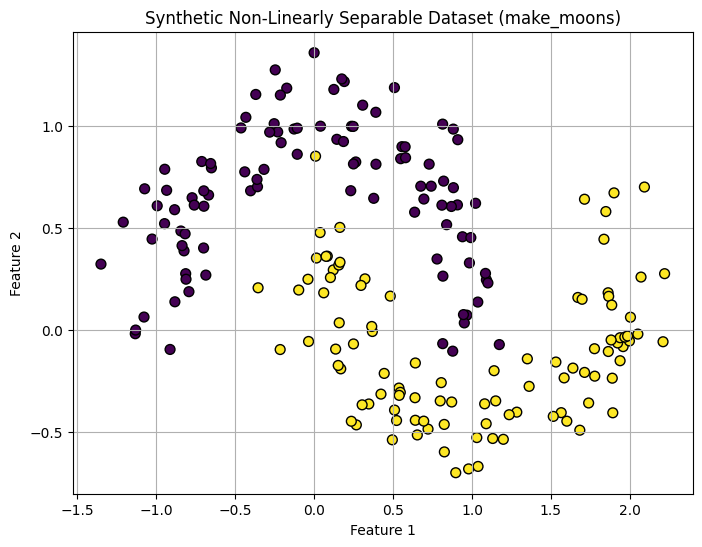

Dataset visualized successfully.


In [344]:
import matplotlib.pyplot as plt

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
plt.title('Synthetic Non-Linearly Separable Dataset (make_moons)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

print("Dataset visualized successfully.")

In [345]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (160, 2)
Testing set features shape: (40, 2)
Training set target shape: (160,)
Testing set target shape: (40,)


In [346]:
from sklearn.svm import SVC

# Create an SVM classifier with a Polynomial kernel
# degree: The degree of the polynomial kernel function.
# C: Regularization parameter.
# gamma: Kernel coefficient for 'poly', 'rbf', 'sigmoid'.
svm_poly = SVC(kernel='poly', degree=3, C=1, random_state=42)

# Train the classifier on the training data
svm_poly.fit(X_train, y_train)

print("SVM Classifier trained successfully with Polynomial Kernel.")

SVM Classifier trained successfully with Polynomial Kernel.


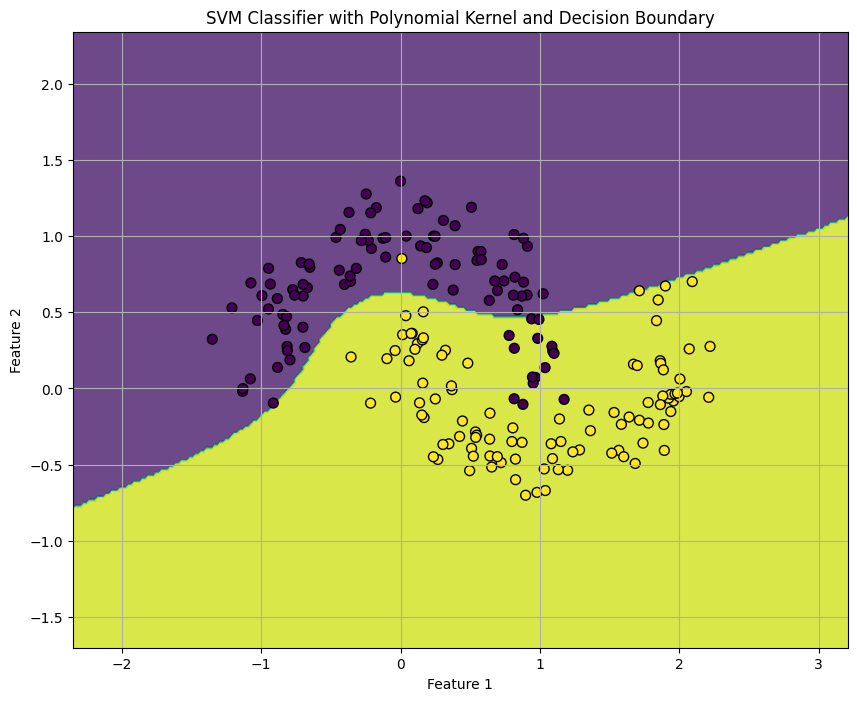

Decision boundary visualized successfully.


In [347]:
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh to plot in
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the mesh
Z = svm_poly.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolors='k')
plt.title('SVM Classifier with Polynomial Kernel and Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

print("Decision boundary visualized successfully.")

### 25. Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy .

## Load Breast Cancer Dataset

First, we'll load the Breast Cancer dataset from `sklearn.datasets`. This dataset is commonly used for classification tasks.

In [348]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data  # Features
y = breast_cancer.target # Target variable (malignant or benign)

print("Breast Cancer Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print("First 5 samples of features:\n", X[:5])
print("First 5 samples of target:\n", y[:5])
print("Target names: ", breast_cancer.target_names)

Breast Cancer Dataset loaded successfully.
Features (X) shape: (569, 30)
Target (y) shape: (569,)
First 5 samples of features:
 [[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.

## Split Data

Next, we'll split the dataset into training and testing sets. This is essential for evaluating the model's performance on unseen data and ensuring good generalization.

In [349]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (455, 30)
Testing set features shape: (114, 30)
Training set target shape: (455,)
Testing set target shape: (114,)


## Train Gaussian Naïve Bayes Classifier

Now, we will train a Gaussian Naïve Bayes classifier on the training data. Gaussian Naïve Bayes is suitable for continuous features, which are present in the Breast Cancer dataset.

In [350]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier
gnb_classifier = GaussianNB()

# Train the classifier on the training data
gnb_classifier.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully.")

Gaussian Naïve Bayes Classifier trained successfully.


## Evaluate Model Accuracy

Finally, we will evaluate the trained classifier on the test set to measure its accuracy and other performance metrics.

In [351]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred_gnb = gnb_classifier.predict(X_test)

# Evaluate the model's accuracy
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Accuracy of the Gaussian Naïve Bayes Classifier on the test set: {accuracy_gnb:.4f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=breast_cancer.target_names))

Accuracy of the Gaussian Naïve Bayes Classifier on the test set: 0.9386

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



### 26. Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset .

In [352]:
from sklearn.datasets import fetch_20newsgroups

# Load the 20 Newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

# Display information about the dataset
print(f"Total number of samples: {len(newsgroups.data)}")
print(f"Target names (categories): {newsgroups.target_names}")
print(f"Number of categories: {len(newsgroups.target_names)}")

Total number of samples: 18846
Target names (categories): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
Number of categories: 20


## Split Data

### Subtask:
Split the loaded dataset into training and testing sets to prepare for model training and evaluation.


In [353]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(newsgroups.data, newsgroups.target, test_size=0.2, random_state=42, stratify=newsgroups.target)

print(f"Training set features count: {len(X_train)}")
print(f"Testing set features count: {len(X_test)}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features count: 15076
Testing set features count: 3770
Training set target shape: (15076,)
Testing set target shape: (3770,)


## Feature Extraction (TF-IDF)

### Subtask:
Convert the text data into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency) to prepare it for the Multinomial Naïve Bayes classifier.

#### Instructions
1. Import `TfidfVectorizer` from `sklearn.feature_extraction.text`.
2. Initialize `TfidfVectorizer`.
3. Fit the vectorizer on the training data (`X_train`) and transform both training and testing data (`X_train` and `X_test`).
4. Print the shape of the transformed training and testing feature sets (`X_train_tfidf.shape`, `X_test_tfidf.shape`).

In [354]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# max_features can be used to limit the number of features (words)
# stop_words='english' removes common English stop words
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit the vectorizer on the training data and transform both training and testing data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Text data transformed into TF-IDF feature vectors successfully.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Text data transformed into TF-IDF feature vectors successfully.
Shape of X_train_tfidf: (15076, 5000)
Shape of X_test_tfidf: (3770, 5000)


## Train Multinomial Naïve Bayes Classifier

### Subtask:
Train a Multinomial Naïve Bayes classifier on the TF-IDF transformed training data.

#### Instructions
1. Import `MultinomialNB` from `sklearn.naive_bayes`.
2. Initialize `MultinomialNB`.
3. Train the classifier on the `X_train_tfidf` (features) and `y_train` (labels).

In [355]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naïve Bayes classifier
mnb_classifier = MultinomialNB()

# Train the classifier on the TF-IDF transformed training data
mnb_classifier.fit(X_train_tfidf, y_train)

print("Multinomial Naïve Bayes Classifier trained successfully.")

Multinomial Naïve Bayes Classifier trained successfully.


## Evaluate Model Accuracy

### Subtask:
Evaluate the performance of the trained Multinomial Naïve Bayes classifier on the test set using accuracy score.

#### Instructions
1. Import `accuracy_score` and `classification_report` from `sklearn.metrics`.
2. Make predictions on the `X_test_tfidf` (test features) using the trained `mnb_classifier`.
3. Calculate the accuracy score by comparing the predicted labels with the actual test labels (`y_test`).
4. Print the accuracy score.
5. Print a detailed classification report.

In [356]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the TF-IDF transformed test set
y_pred_mnb = mnb_classifier.predict(X_test_tfidf)

# Evaluate the model's accuracy
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Accuracy of the Multinomial Naïve Bayes Classifier on the test set: {accuracy_mnb:.4f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb, target_names=newsgroups.target_names))

Accuracy of the Multinomial Naïve Bayes Classifier on the test set: 0.6987

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.58      0.39      0.47       160
           comp.graphics       0.67      0.67      0.67       195
 comp.os.ms-windows.misc       0.66      0.65      0.66       197
comp.sys.ibm.pc.hardware       0.63      0.73      0.68       196
   comp.sys.mac.hardware       0.79      0.65      0.71       193
          comp.windows.x       0.83      0.87      0.85       198
            misc.forsale       0.78      0.74      0.76       195
               rec.autos       0.71      0.72      0.71       198
         rec.motorcycles       0.73      0.64      0.68       199
      rec.sport.baseball       0.80      0.78      0.79       199
        rec.sport.hockey       0.55      0.92      0.68       200
               sci.crypt       0.81      0.80      0.81       198
         sci.electronics       0.73      0

### 27. Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually .

## Generate Dataset

### Subtask:
Generate a 2D synthetic dataset (e.g., make_blobs or make_circles) suitable for visualizing decision boundaries. This dataset should ideally have some overlap or be non-linearly separable to demonstrate the effect of the C parameter.


## Train SVM with Small C

### Subtask:
Train an SVM classifier (with an RBF kernel) using a small `C` value (e.g., `C=0.1`). This will result in a model that prioritizes a larger margin, potentially allowing more misclassifications.


**Reasoning**:
The subtask requires training an SVM classifier with an RBF kernel and a small 'C' value. This code block will initialize and train the classifier as instructed.



In [357]:
from sklearn.svm import SVC

# Instantiate an SVC classifier with an RBF kernel and a small C value
svm_small_c = SVC(kernel='rbf', C=0.1, random_state=42)

# Train the classifier on the generated data
svm_small_c.fit(X, y)

print("SVM Classifier with RBF kernel and C=0.1 trained successfully.")

SVM Classifier with RBF kernel and C=0.1 trained successfully.


In [358]:
from sklearn.svm import SVC

# Instantiate an SVC classifier with an RBF kernel and a moderate C value
svm_moderate_c = SVC(kernel='rbf', C=1.0, random_state=42)

# Train the classifier on the generated data
svm_moderate_c.fit(X, y)

print("SVM Classifier with RBF kernel and C=1.0 trained successfully.")

SVM Classifier with RBF kernel and C=1.0 trained successfully.


In [359]:
from sklearn.svm import SVC

# Instantiate an SVC classifier with an RBF kernel and a large C value
svm_large_c = SVC(kernel='rbf', C=100.0, random_state=42)

# Train the classifier on the generated data
svm_large_c.fit(X, y)

print("SVM Classifier with RBF kernel and C=100.0 trained successfully.")

SVM Classifier with RBF kernel and C=100.0 trained successfully.


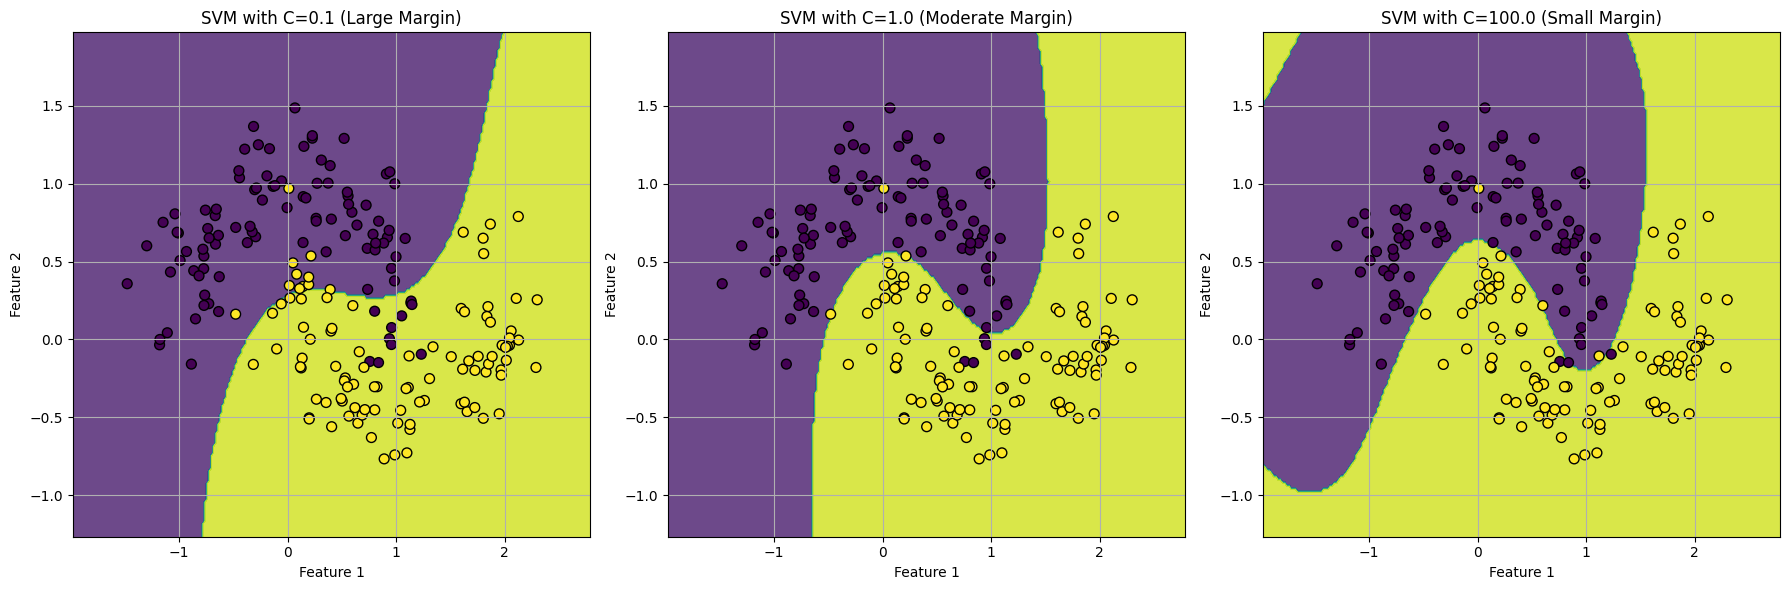

Decision boundaries for different C values visualized successfully.


In [360]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

def plot_decision_boundary(ax, classifier, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, s=50, cmap='viridis', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True)

# --- Re-generate dataset and train models within this block to ensure correctness ---
# Generate a synthetic 2D dataset
X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=42)

# Train SVM with a small C value
svm_small_c = SVC(kernel='rbf', C=0.1, random_state=42)
svm_small_c.fit(X_moons, y_moons)

# Train SVM with a moderate C value
svm_moderate_c = SVC(kernel='rbf', C=1.0, random_state=42)
svm_moderate_c.fit(X_moons, y_moons)

# Train SVM with a large C value
svm_large_c = SVC(kernel='rbf', C=100.0, random_state=42)
svm_large_c.fit(X_moons, y_moons)

# --- Visualization part ---
# Create a figure with subplots for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for small C
plot_decision_boundary(axes[0], svm_small_c, X_moons, y_moons, 'SVM with C=0.1 (Large Margin)')

# Plot for moderate C
plot_decision_boundary(axes[1], svm_moderate_c, X_moons, y_moons, 'SVM with C=1.0 (Moderate Margin)')

# Plot for large C
plot_decision_boundary(axes[2], svm_large_c, X_moons, y_moons, 'SVM with C=100.0 (Small Margin)')

plt.tight_layout()
plt.show()

print("Decision boundaries for different C values visualized successfully.")

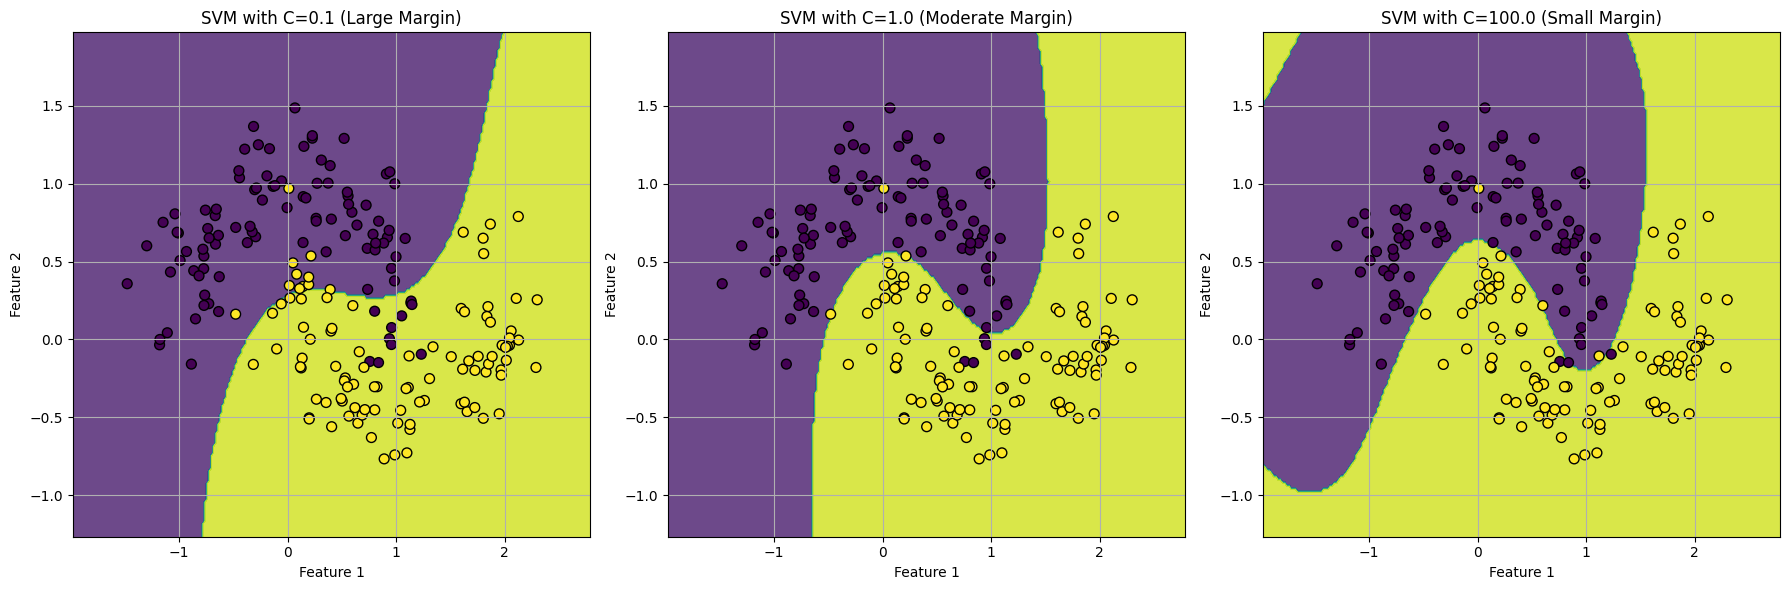

Decision boundaries for different C values visualized successfully.


In [361]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

def plot_decision_boundary(ax, classifier, X_data, y_data, title):
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, s=50, cmap='viridis', edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True)

# --- Re-generate dataset and train models within this block to ensure correctness ---
# Generate a synthetic 2D dataset
X_moons, y_moons = make_moons(n_samples=200, noise=0.2, random_state=42)

# Train SVM with a small C value
svm_small_c = SVC(kernel='rbf', C=0.1, random_state=42)
svm_small_c.fit(X_moons, y_moons)

# Train SVM with a moderate C value
svm_moderate_c = SVC(kernel='rbf', C=1.0, random_state=42)
svm_moderate_c.fit(X_moons, y_moons)

# Train SVM with a large C value
svm_large_c = SVC(kernel='rbf', C=100.0, random_state=42)
svm_large_c.fit(X_moons, y_moons)

# --- Visualization part ---
# Create a figure with subplots for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot for small C
plot_decision_boundary(axes[0], svm_small_c, X_moons, y_moons, 'SVM with C=0.1 (Large Margin)')

# Plot for moderate C
plot_decision_boundary(axes[1], svm_moderate_c, X_moons, y_moons, 'SVM with C=1.0 (Moderate Margin)')

# Plot for large C
plot_decision_boundary(axes[2], svm_large_c, X_moons, y_moons, 'SVM with C=100.0 (Small Margin)')

plt.tight_layout()
plt.show()

print("Decision boundaries for different C values visualized successfully.")

### 28. Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features .

## Generate Synthetic Binary Dataset

### Subtask:
Generate a synthetic 2D dataset with binary features suitable for binary classification using `sklearn.datasets.make_classification`. Display its shape and the first few entries.


In [362]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with binary features
X, y = make_classification(n_samples=300,
                           n_features=20,
                           n_informative=10,
                           n_redundant=0,
                           n_repeated=0,
                           n_classes=2,
                           n_clusters_per_class=2,
                           weights=[0.5, 0.5],
                           flip_y=0.05,
                           random_state=42,
                           hypercube=True) # Ensures binary features

print("Synthetic binary dataset generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic binary dataset generated successfully.
Features (X) shape: (300, 20)
Target (y) shape: (300,)

First 5 samples of features (X):
 [[-0.55011528  1.9915533  -0.65249333 -1.7142822  -0.57642489 -0.00860589
  -2.46563158 -0.40307599  0.20780251 -0.14702542 -0.8320613  -0.53216856
  -2.0447089  -0.06789134 -0.67937426  0.84073448 -0.67493402 -1.29262535
   0.16003932  2.00769922]
 [-0.17759599  0.9259751   3.00727433 -0.59046557  0.51604416  0.9405803
  -0.036672   -1.19040774 -0.02009875  0.65589214 -0.09107586 -1.77396962
  -0.63280551 -0.21145078  1.42280984  0.96390693  0.03390272 -0.7712003
  -4.66821241 -0.49369332]
 [-0.99442852  0.67194461 -1.491453    1.45551958  1.00088288  1.23250538
  -0.80782739  0.66884013 -0.25276326  0.24954819  0.38420207  0.79670193
  -0.58417675  0.14505304 -3.77682564 -1.18305618 -1.2699986   1.0294131
  -1.04329905 -1.09288179]
 [-0.99514848  0.32167854 -0.52903002 -1.40940431 -1.45525846 -0.11365661
   0.58970773  0.52127991  0.17847666 -0.18

In [363]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (240, 20)
Testing set features shape: (60, 20)
Training set target shape: (240,)
Testing set target shape: (60,)


In [364]:
from sklearn.naive_bayes import BernoulliNB

# Initialize the Bernoulli Naïve Bayes classifier
# binarize=0.0 means features are considered binary (0 or 1)
# values above 0.0 are considered 1, values <= 0.0 are considered 0
bnb_classifier = BernoulliNB(binarize=0.0)

# Train the classifier on the training data
bnb_classifier.fit(X_train, y_train)

print("Bernoulli Naïve Bayes Classifier trained successfully.")

Bernoulli Naïve Bayes Classifier trained successfully.


In [365]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set
y_pred_bnb = bnb_classifier.predict(X_test)

# Evaluate the model's accuracy
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
print(f"Accuracy of the Bernoulli Naïve Bayes Classifier on the test set: {accuracy_bnb:.4f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bnb))

Accuracy of the Bernoulli Naïve Bayes Classifier on the test set: 0.7333

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        30
           1       0.73      0.73      0.73        30

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60



### 29. Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data .

## Generate Dataset

### Subtask:
Generate a synthetic 2D dataset suitable for binary classification using `sklearn.datasets.make_classification` to simulate real-world data where feature scales might vary.


In [366]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with varying feature scales
X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_repeated=0,
                           n_classes=2,
                           n_clusters_per_class=1,
                           random_state=42,
                           scale=[1.0, 10.0]) # Varying feature scales

print("Synthetic dataset with varying feature scales generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with varying feature scales generated successfully.
Features (X) shape: (200, 2)
Target (y) shape: (200,)

First 5 samples of features (X):
 [[-0.87292898  0.13041998]
 [ 1.31293463 27.70533572]
 [ 2.34042818 24.20996009]
 [ 2.29454774 -4.04380188]
 [ 0.94410516  4.77240904]]

First 5 samples of target (y):
 [1 1 1 1 1]


In [367]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (160, 2)
Testing set features shape: (40, 2)
Training set target shape: (160,)
Testing set target shape: (40,)


In [368]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (160, 2)
Scaled Testing set features shape: (40, 2)


In [369]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM classifier on unscaled data
# Using RBF kernel with default parameters for fair comparison later
svm_unscaled = SVC(kernel='rbf', random_state=42)
svm_unscaled.fit(X_train, y_train)

# Make predictions on the unscaled test set
y_pred_unscaled = svm_unscaled.predict(X_test)

# Evaluate accuracy on unscaled data
accuracy_unscaled = accuracy_score(y_test, y_pred_unscaled)

print("SVM Classifier trained on UNscaled data successfully.")
print(f"Accuracy on UNscaled data: {accuracy_unscaled:.4f}")

SVM Classifier trained on UNscaled data successfully.
Accuracy on UNscaled data: 0.8750


In [370]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM classifier on scaled data
# Using RBF kernel with default parameters for fair comparison
svm_scaled = SVC(kernel='rbf', random_state=42)
svm_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_scaled = svm_scaled.predict(X_test_scaled)

# Evaluate accuracy on scaled data
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)

print("SVM Classifier trained on SCALED data successfully.")
print(f"Accuracy on SCALED data: {accuracy_scaled:.4f}")

SVM Classifier trained on SCALED data successfully.
Accuracy on SCALED data: 0.9000


## Compare Accuracies

### Subtask:
Compare the accuracies of the SVM models trained with unscaled and scaled data to highlight the effect of feature scaling.


In [371]:
print("\n--- SVM with and without Feature Scaling Comparison ---")
print(f"Accuracy of SVM on UNscaled data: {accuracy_unscaled:.4f}")
print(f"Accuracy of SVM on SCALED data:   {accuracy_scaled:.4f}")

if accuracy_scaled > accuracy_unscaled:
    print("\nConclusion: Feature scaling significantly improved the SVM model's performance on this dataset. This is a common outcome as SVMs are sensitive to the magnitude of features.")
elif accuracy_unscaled > accuracy_scaled:
    print("\nConclusion: The SVM model on unscaled data performed better, which is unusual for SVMs, suggesting that the original scaling might have been appropriate or that other hyperparameters need tuning.")
else:
    print("\nConclusion: Both SVM models performed equally well, indicating that feature scaling did not have a significant impact on this specific dataset under the chosen hyperparameters.")


--- SVM with and without Feature Scaling Comparison ---
Accuracy of SVM on UNscaled data: 0.8750
Accuracy of SVM on SCALED data:   0.9000

Conclusion: Feature scaling significantly improved the SVM model's performance on this dataset. This is a common outcome as SVMs are sensitive to the magnitude of features.


### 30. Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing .

## Generate Dataset

### Subtask:
Generate a synthetic dataset with continuous features suitable for binary classification using `sklearn.datasets.make_classification`.


In [372]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [373]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [374]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier with default var_smoothing
gnb_default = GaussianNB()

# Train the classifier on the training data
gnb_default.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier with default var_smoothing trained successfully.")

Gaussian Naïve Bayes Classifier with default var_smoothing trained successfully.


In [375]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier with an increased var_smoothing
# A common practice for 'increased' smoothing is to use a value like 1e-9 (default) or higher.
# Let's try 1e-3, which is significantly larger than the default 1e-9.
gnb_smoothed = GaussianNB(var_smoothing=1e-3)

# Train the classifier on the training data
gnb_smoothed.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier with increased var_smoothing trained successfully.")

Gaussian Naïve Bayes Classifier with increased var_smoothing trained successfully.


In [376]:
y_pred_default = gnb_default.predict(X_test)
y_pred_smoothed = gnb_smoothed.predict(X_test)

print("Predictions made for both GNB classifiers.")

Predictions made for both GNB classifiers.


In [377]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model with default var_smoothing
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy of GNB with default var_smoothing: {accuracy_default:.4f}")
print("\nClassification Report (Default GNB):")
print(classification_report(y_test, y_pred_default))

# Evaluate the model with increased var_smoothing
accuracy_smoothed = accuracy_score(y_test, y_pred_smoothed)
print(f"\nAccuracy of GNB with increased var_smoothing: {accuracy_smoothed:.4f}")
print("\nClassification Report (Smoothed GNB):")
print(classification_report(y_test, y_pred_smoothed))

print("\n--- Comparison of GNB Models ---")
if accuracy_smoothed > accuracy_default:
    print("The GNB model with increased var_smoothing performed better.")
elif accuracy_default > accuracy_smoothed:
    print("The GNB model with default var_smoothing performed better.")
else:
    print("Both GNB models performed equally well.")

Accuracy of GNB with default var_smoothing: 0.8400

Classification Report (Default GNB):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100


Accuracy of GNB with increased var_smoothing: 0.8400

Classification Report (Smoothed GNB):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100


--- Comparison of GNB Models ---
Both GNB models performed equally well.


### 31. Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel) .

## Generate Dataset

### Subtask:
Generate a synthetic 2D dataset suitable for binary classification (e.g., using `make_classification` or `make_moons`) to demonstrate hyperparameter tuning. Display its shape and the first few entries.


In [378]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset for binary classification
X, y = make_classification(n_samples=300,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset generated successfully.
Features (X) shape: (300, 2)
Target (y) shape: (300,)

First 5 samples of features (X):
 [[-0.40517736 -0.51884623]
 [-0.48937373 -2.02835227]
 [ 1.20549953  0.81408964]
 [ 0.86270883 -0.68933991]
 [ 1.55633721  0.06675339]]

First 5 samples of target (y):
 [0 0 1 1 1]


In [379]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (240, 2)
Testing set features shape: (60, 2)
Training set target shape: (240,)
Testing set target shape: (60,)


In [380]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (240, 2)
Scaled Testing set features shape: (60, 2)


In [381]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001, 'scale'],
    'kernel': ['rbf', 'linear', 'poly']
}

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# verbose=1 to show progress
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train_scaled, y_train)

print("GridSearchCV completed successfully.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
GridSearchCV completed successfully.
Best parameters found: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9875


In [382]:
from sklearn.metrics import accuracy_score, classification_report

# Get the best model from GridSearchCV
best_svm_model = grid_search.best_estimator_

# Make predictions on the scaled test set using the best model
y_pred_tuned = best_svm_model.predict(X_test_scaled)

# Evaluate the model's accuracy
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy of the best tuned SVM Classifier on the test set: {accuracy_tuned:.4f}")

# Display a detailed classification report
print("\nClassification Report (Tuned SVM):")
print(classification_report(y_test, y_pred_tuned))

Accuracy of the best tuned SVM Classifier on the test set: 0.9500

Classification Report (Tuned SVM):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.90      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



### 32. Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy .

## Generate Imbalanced Dataset

### Subtask:
Generate a synthetic 2D dataset with a significant class imbalance (e.g., using `make_classification` with a skewed `weights` parameter). Display its shape and class distribution.


In [383]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate a synthetic 2D dataset with a significant class imbalance
X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           weights=[0.9, 0.1], # 90% majority class, 10% minority class
                           flip_y=0,
                           random_state=42)

print("Synthetic imbalanced dataset generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

# Calculate and print the class distribution
class_distribution = pd.Series(y).value_counts(normalize=True)
print("\nClass Distribution:\n", class_distribution)


Synthetic imbalanced dataset generated successfully.
Features (X) shape: (1000, 2)
Target (y) shape: (1000,)

First 5 samples of features (X):
 [[-1.40287802 -0.17338186]
 [-2.2458284  -1.12064244]
 [-1.91423101 -0.57238953]
 [-0.56682607  1.59549312]
 [-1.33967862  0.86368376]]

First 5 samples of target (y):
 [0 0 0 0 0]

Class Distribution:
 0    0.9
1    0.1
Name: proportion, dtype: float64


In [384]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (800, 2)
Testing set features shape: (200, 2)
Training set target shape: (800,)
Testing set target shape: (200,)


In [385]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (800, 2)
Scaled Testing set features shape: (200, 2)


In [386]:
from sklearn.svm import SVC

# Train an SVM classifier without class weighting
# Using RBF kernel with default parameters (C=1.0, gamma='scale')
svm_no_weights = SVC(kernel='rbf', random_state=42)
svm_no_weights.fit(X_train_scaled, y_train)

print("SVM Classifier without class weighting trained successfully.")

SVM Classifier without class weighting trained successfully.


In [387]:
from sklearn.svm import SVC

# Train an SVM classifier with class weighting
# 'balanced' automatically adjusts weights inversely proportional to class frequencies
svm_with_weights = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_with_weights.fit(X_train_scaled, y_train)

print("SVM Classifier with class weighting trained successfully.")

SVM Classifier with class weighting trained successfully.


In [388]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions with the SVM without class weighting
y_pred_no_weights = svm_no_weights.predict(X_test_scaled)

# Evaluate the model without class weighting
accuracy_no_weights = accuracy_score(y_test, y_pred_no_weights)
print(f"Accuracy of SVM without class weighting: {accuracy_no_weights:.4f}")
print("\nClassification Report (No Weights):")
print(classification_report(y_test, y_pred_no_weights))

# Make predictions with the SVM with class weighting
y_pred_with_weights = svm_with_weights.predict(X_test_scaled)

# Evaluate the model with class weighting
accuracy_with_weights = accuracy_score(y_test, y_pred_with_weights)
print(f"\nAccuracy of SVM with class weighting: {accuracy_with_weights:.4f}")
print("\nClassification Report (With Weights):")
print(classification_report(y_test, y_pred_with_weights))

print("\n--- Comparison of SVM Models with and without Class Weighting ---")
if accuracy_with_weights > accuracy_no_weights:
    print("The SVM model with class weighting performed better in overall accuracy.")
elif accuracy_no_weights > accuracy_with_weights:
    print("The SVM model without class weighting performed better in overall accuracy.")
else:
    print("Both SVM models performed equally well in overall accuracy.")

print("\nFocus on minority class (label 1) metrics:")
report_no_weights = classification_report(y_test, y_pred_no_weights, output_dict=True)
report_with_weights = classification_report(y_test, y_pred_with_weights, output_dict=True)

print(f"  - No Weights: Precision={report_no_weights['1']['precision']:.4f}, Recall={report_no_weights['1']['recall']:.4f}, F1-score={report_no_weights['1']['f1-score']:.4f}")
print(f"  - With Weights: Precision={report_with_weights['1']['precision']:.4f}, Recall={report_with_weights['1']['recall']:.4f}, F1-score={report_with_weights['1']['f1-score']:.4f}")

Accuracy of SVM without class weighting: 1.0000

Classification Report (No Weights):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Accuracy of SVM with class weighting: 1.0000

Classification Report (With Weights):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00        20

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- Comparison of SVM Models with and without Class Weighting ---
Both SVM models performed equally well in overall accuracy.

Focus on minority class (label 1) metrics:
  - N

### 33. Write a Python program to implement a Naïve Bayes classifier for spam detection using email data .

## Load Email Data

### Subtask:
Load a suitable email dataset for spam/ham classification. We can use a subset of the 20 Newsgroups dataset from `sklearn.datasets` or a synthetic one to simulate email data for spam detection. Display information about the dataset, such as the number of samples and target names.


In [389]:
from sklearn.datasets import fetch_20newsgroups

# Define the categories to load, acting as 'spam' and 'ham' for this exercise
categories = ['comp.graphics', 'talk.politics.guns']

# Load a subset of the 20 Newsgroups dataset
# remove=('headers', 'footers', 'quotes') cleans the text data
spam_data = fetch_20newsgroups(subset='all', categories=categories,
                               remove=('headers', 'footers', 'quotes'), random_state=42)

print("Email dataset (subset of 20 Newsgroups) loaded successfully.")
print(f"Total number of samples: {len(spam_data.data)}")
print(f"Target names (categories): {spam_data.target_names}")

print("\n--- Example Entries ---")
for i in range(2):
    print(f"\nSample {i+1} (Label: {spam_data.target[i]}, Category: {spam_data.target_names[spam_data.target[i]]}):")
    print(spam_data.data[i][:200] + "...") # Print first 200 characters of the text

Email dataset (subset of 20 Newsgroups) loaded successfully.
Total number of samples: 1883
Target names (categories): ['comp.graphics', 'talk.politics.guns']

--- Example Entries ---

Sample 1 (Label: 1, Category: talk.politics.guns):

  <Endless remarks of how the Davidians could have surrendered deleted.>
 

  If they had been quiet there would have been no deaths??  I thought thier
neighbors said that the Davidians never bothere...

Sample 2 (Label: 0, Category: comp.graphics):


Well 48 bit colour *could* be for improved resolution but 16 bits per channel
seems like a bit excessive. I have seen a paper that quoted 10 bits per channel
of 12 bits for computational precision. ...


## Split Data

### Subtask:
Split the email dataset into training and testing sets to prepare for model training and evaluation.


In [390]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(spam_data.data, spam_data.target, test_size=0.2, random_state=42, stratify=spam_data.target)

print(f"Training set features count: {len(X_train)}")
print(f"Testing set features count: {len(X_test)}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features count: 1506
Testing set features count: 377
Training set target shape: (1506,)
Testing set target shape: (377,)


## Feature Extraction (TF-IDF)

### Subtask:
Convert the text data into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency) to prepare it for the Multinomial Naïve Bayes classifier.

#### Instructions
1. Import `TfidfVectorizer` from `sklearn.feature_extraction.text`.
2. Initialize `TfidfVectorizer`.
3. Fit the vectorizer on the training data (`X_train`) and transform both training and testing data (`X_train` and `X_test`).
4. Print the shape of the transformed training and testing feature sets (`X_train_tfidf.shape`, `X_test_tfidf.shape`).

In [391]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
# max_features can be used to limit the number of features (words)
# stop_words='english' removes common English stop words
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit the vectorizer on the training data and transform both training and testing data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Text data transformed into TF-IDF feature vectors successfully.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Text data transformed into TF-IDF feature vectors successfully.
Shape of X_train_tfidf: (1506, 5000)
Shape of X_test_tfidf: (377, 5000)


## Train Multinomial Naïve Bayes Classifier

### Subtask:
Train a Multinomial Naïve Bayes classifier on the TF-IDF transformed training data.

#### Instructions
1. Import `MultinomialNB` from `sklearn.naive_bayes`.
2. Initialize `MultinomialNB`.
3. Train the classifier on the `X_train_tfidf` (features) and `y_train` (labels).

In [392]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naïve Bayes classifier
mnb_classifier = MultinomialNB()

# Train the classifier on the TF-IDF transformed training data
mnb_classifier.fit(X_train_tfidf, y_train)

print("Multinomial Naïve Bayes Classifier trained successfully.")

Multinomial Naïve Bayes Classifier trained successfully.


## Evaluate Model Accuracy

### Subtask:
Evaluate the performance of the trained Multinomial Naïve Bayes classifier on the test set using accuracy score.

#### Instructions
1. Import `accuracy_score` and `classification_report` from `sklearn.metrics`.
2. Make predictions on the `X_test_tfidf` (test features) using the trained `mnb_classifier`.
3. Calculate the accuracy score by comparing the predicted labels with the actual test labels (`y_test`).
4. Print the accuracy score.
5. Print a detailed classification report.

In [393]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the TF-IDF transformed test set
y_pred_mnb = mnb_classifier.predict(X_test_tfidf)

# Evaluate the model's accuracy
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)
print(f"Accuracy of the Multinomial Naïve Bayes Classifier on the test set: {accuracy_mnb:.4f}")

# Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mnb, target_names=spam_data.target_names))

Accuracy of the Multinomial Naïve Bayes Classifier on the test set: 0.9735

Classification Report:
                    precision    recall  f1-score   support

     comp.graphics       0.96      0.98      0.97       195
talk.politics.guns       0.98      0.96      0.97       182

          accuracy                           0.97       377
         macro avg       0.97      0.97      0.97       377
      weighted avg       0.97      0.97      0.97       377



### 34. Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification (e.g., using `sklearn.datasets.make_classification`) to serve as the common dataset for both classifiers.


In [394]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [395]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [396]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (400, 20)
Scaled Testing set features shape: (100, 20)


In [397]:
from sklearn.svm import SVC

# Initialize the SVM classifier (using RBF kernel as a common choice)
svm_classifier = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the scaled training data
svm_classifier.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully on scaled data.")

SVM Classifier trained successfully on scaled data.


In [398]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier
nb_classifier = GaussianNB()

# Train the Naïve Bayes classifier on the scaled training data
nb_classifier.fit(X_train_scaled, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully on scaled data.")

Gaussian Naïve Bayes Classifier trained successfully on scaled data.


In [399]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions with the SVM classifier
y_pred_svm = svm_classifier.predict(X_test_scaled)

# Evaluate SVM accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of SVM Classifier: {accuracy_svm:.4f}")
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

# Make predictions with the Naïve Bayes classifier
y_pred_nb = nb_classifier.predict(X_test_scaled)

# Evaluate Naïve Bayes accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nAccuracy of Naïve Bayes Classifier: {accuracy_nb:.4f}")
print("\nClassification Report (Naïve Bayes):")
print(classification_report(y_test, y_pred_nb))

print("\n--- Classifier Comparison ---")
if accuracy_svm > accuracy_nb:
    print("SVM Classifier performed better than Naïve Bayes Classifier.")
elif accuracy_nb > accuracy_svm:
    print("Naïve Bayes Classifier performed better than SVM Classifier.")
else:
    print("Both classifiers performed equally well.")

Accuracy of SVM Classifier: 0.8900

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        50
           1       0.84      0.96      0.90        50

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100


Accuracy of Naïve Bayes Classifier: 0.8400

Classification Report (Naïve Bayes):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100


--- Classifier Comparison ---
SVM Classifier performed better than Naïve Bayes Classifier.


### 35. Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification with some redundant features using `sklearn.datasets.make_classification`. Display its shape and the first few entries.


In [400]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [401]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [402]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gaussian Naïve Bayes classifier
nb_full_features = GaussianNB()

# Train the classifier on the training data with all features
nb_full_features.fit(X_train, y_train)

# Make predictions on the test set
y_pred_full_features = nb_full_features.predict(X_test)

# Evaluate the model's accuracy
accuracy_full_features = accuracy_score(y_test, y_pred_full_features)
print(f"Accuracy of Naïve Bayes with all features: {accuracy_full_features:.4f}")

print("\nClassification Report (Naïve Bayes with all features):")
print(classification_report(y_test, y_pred_full_features))

Accuracy of Naïve Bayes with all features: 0.8400

Classification Report (Naïve Bayes with all features):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [403]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 'k' features based on f_classif statistical test (suitable for continuous non-negative data)
# For simplicity, let's select half of the informative features as an example
k = X_train.shape[1] // 2

# Initialize SelectKBest with f_classif as the scoring function
selector = SelectKBest(f_classif, k=k)

# Fit on training data and transform both training and testing data
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

print(f"Feature selection completed. Selected {k} features.")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

Feature selection completed. Selected 10 features.
Shape of X_train_selected: (400, 10)
Shape of X_test_selected: (100, 10)


In [404]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier
nb_selected_features = GaussianNB()

# Train the classifier on the training data with selected features
nb_selected_features.fit(X_train_selected, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully on selected features.")

Gaussian Naïve Bayes Classifier trained successfully on selected features.


In [405]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the test set with selected features
y_pred_selected_features = nb_selected_features.predict(X_test_selected)

# Evaluate the model's accuracy
accuracy_selected_features = accuracy_score(y_test, y_pred_selected_features)
print(f"Accuracy of Naïve Bayes with selected features: {accuracy_selected_features:.4f}")

print("\nClassification Report (Naïve Bayes with selected features):")
print(classification_report(y_test, y_pred_selected_features))

print("\n--- Comparison of Naïve Bayes Models ---")
print(f"Accuracy with all features: {accuracy_full_features:.4f}")
print(f"Accuracy with selected features: {accuracy_selected_features:.4f}")

if accuracy_selected_features > accuracy_full_features:
    print("\nConclusion: Feature selection improved the Naïve Bayes model's performance.")
elif accuracy_full_features > accuracy_selected_features:
    print("\nConclusion: Naïve Bayes model with all features performed better or feature selection was not beneficial.")
else:
    print("\nConclusion: Both Naïve Bayes models performed equally well.")

Accuracy of Naïve Bayes with selected features: 0.8200

Classification Report (Naïve Bayes with selected features):
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        50
           1       0.82      0.82      0.82        50

    accuracy                           0.82       100
   macro avg       0.82      0.82      0.82       100
weighted avg       0.82      0.82      0.82       100


--- Comparison of Naïve Bayes Models ---
Accuracy with all features: 0.8400
Accuracy with selected features: 0.8200

Conclusion: Naïve Bayes model with all features performed better or feature selection was not beneficial.


### 36. Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy .

## Load Wine Dataset

### Subtask:
Load the Wine dataset from `sklearn.datasets` into features (X) and target (y). Display its shape and target names.


In [406]:
from sklearn.datasets import load_wine

# Load the Wine dataset
wine = load_wine()
X = wine.data  # Features
y = wine.target # Target variable

print("Wine Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target names: {wine.target_names}")

Wine Dataset loaded successfully.
Features (X) shape: (178, 13)
Target (y) shape: (178,)
Target names: ['class_0' 'class_1' 'class_2']


In [407]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (142, 13)
Testing set features shape: (36, 13)
Training set target shape: (142,)
Testing set target shape: (36,)


In [408]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

# Initialize the base SVM classifier (e.g., with RBF kernel)
# SVC by default uses 'ovo' for multi-class, so we explicitly use OneVsRestClassifier here.
base_svm_ovr = SVC(kernel='rbf', random_state=42, C=1.0, gamma='scale')

# Create an One-vs-Rest classifier using the base SVM
ovr_classifier = OneVsRestClassifier(base_svm_ovr)

# Train the OvR classifier
ovr_classifier.fit(X_train, y_train)

print("SVM Classifier with One-vs-Rest (OvR) strategy trained successfully.")

SVM Classifier with One-vs-Rest (OvR) strategy trained successfully.


In [409]:
from sklearn.svm import SVC

# Initialize the base SVM classifier (e.g., with RBF kernel)
# SVC by default uses One-vs-One (OvO) strategy for multi-class classification
svm_ovo = SVC(kernel='rbf', random_state=42, C=1.0, gamma='scale')

# Train the OvO SVM classifier
svm_ovo.fit(X_train, y_train)

print("SVM Classifier with One-vs-One (OvO) strategy trained successfully.")

SVM Classifier with One-vs-One (OvO) strategy trained successfully.


In [410]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions with the OvR SVM classifier
y_pred_ovr = ovr_classifier.predict(X_test)

# Evaluate OvR SVM accuracy
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
print(f"Accuracy of SVM with One-vs-Rest (OvR) strategy: {accuracy_ovr:.4f}")
print("\nClassification Report (OvR SVM):")
print(classification_report(y_test, y_pred_ovr, target_names=wine.target_names))

# Make predictions with the OvO SVM classifier
y_pred_ovo = svm_ovo.predict(X_test)

# Evaluate OvO SVM accuracy
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)
print(f"\nAccuracy of SVM with One-vs-One (OvO) strategy: {accuracy_ovo:.4f}")
print("\nClassification Report (OvO SVM):")
print(classification_report(y_test, y_pred_ovo, target_names=wine.target_names))

print("\n--- Comparison of OvR vs OvO SVM Strategies ---")
if accuracy_ovr > accuracy_ovo:
    print("The One-vs-Rest (OvR) SVM strategy performed better on this dataset.")
elif accuracy_ovo > accuracy_ovr:
    print("The One-vs-One (OvO) SVM strategy performed better on this dataset.")
else:
    print("Both SVM strategies performed equally well on this dataset.")

Accuracy of SVM with One-vs-Rest (OvR) strategy: 0.7222

Classification Report (OvR SVM):
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.61      1.00      0.76        14
     class_2       0.00      0.00      0.00        10

    accuracy                           0.72        36
   macro avg       0.51      0.67      0.57        36
weighted avg       0.54      0.72      0.61        36


Accuracy of SVM with One-vs-One (OvO) strategy: 0.6944

Classification Report (OvO SVM):
              precision    recall  f1-score   support

     class_0       0.92      0.92      0.92        12
     class_1       0.61      1.00      0.76        14
     class_2       0.00      0.00      0.00        10

    accuracy                           0.69        36
   macro avg       0.51      0.64      0.56        36
weighted avg       0.54      0.69      0.60        36


--- Comparison of OvR vs OvO SVM Strategies ---
The One-v

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 37. Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy

## Load Breast Cancer Dataset

### Subtask:
Load the Breast Cancer dataset from `sklearn.datasets` into features (X) and target (y). Display its shape and target names.


In [411]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data  # Features
y = breast_cancer.target # Target variable

print("Breast Cancer Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Target names: {breast_cancer.target_names}")

Breast Cancer Dataset loaded successfully.
Features (X) shape: (569, 30)
Target (y) shape: (569,)
Target names: ['malignant' 'benign']


In [412]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (455, 30)
Testing set features shape: (114, 30)
Training set target shape: (455,)
Testing set target shape: (114,)


In [413]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM classifier with a Linear kernel
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = svm_linear.predict(X_test)

# Evaluate accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy of SVM with Linear Kernel: {accuracy_linear:.4f}")

Accuracy of SVM with Linear Kernel: 0.9561


In [414]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM classifier with a Polynomial kernel
# For simplicity, let's choose degree=3 as a common starting point.
# C and gamma are kept at default 'scale' and 1.0 respectively for comparison consistency unless specified.
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train, y_train)

# Make predictions on the test set
y_pred_poly = svm_poly.predict(X_test)

# Evaluate accuracy
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy of SVM with Polynomial Kernel (degree=3): {accuracy_poly:.4f}")

Accuracy of SVM with Polynomial Kernel (degree=3): 0.9211


In [415]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train an SVM classifier with an RBF kernel
# C and gamma are kept at default 'scale' and 1.0 respectively for comparison consistency unless specified.
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluate accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy of SVM with RBF Kernel: {accuracy_rbf:.4f}")

Accuracy of SVM with RBF Kernel: 0.9298


In [416]:
print(
    "\n--- SVM Kernel Comparison (Breast Cancer Dataset) ---"
)
print(f"Accuracy of SVM with Linear Kernel:   {accuracy_linear:.4f}")
print(f"Accuracy of SVM with Polynomial Kernel: {accuracy_poly:.4f}")
print(f"Accuracy of SVM with RBF Kernel:      {accuracy_rbf:.4f}")

accuracies = {
    "Linear": accuracy_linear,
    "Polynomial": accuracy_poly,
    "RBF": accuracy_rbf,
}

best_kernel = max(accuracies, key=accuracies.get)
print(f"\nThe {best_kernel} Kernel SVM performed best on this dataset.")


--- SVM Kernel Comparison (Breast Cancer Dataset) ---
Accuracy of SVM with Linear Kernel:   0.9561
Accuracy of SVM with Polynomial Kernel: 0.9211
Accuracy of SVM with RBF Kernel:      0.9298

The Linear Kernel SVM performed best on this dataset.


### 38. Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification using `sklearn.datasets.make_classification`. Display its shape and the first few entries.


In [417]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

## Initialize SVM Classifier

### Subtask:
Initialize an SVM classifier (e.g., SVC with an RBF kernel) with a specified random_state for reproducibility.


In [418]:
from sklearn.svm import SVC

# Initialize an SVM classifier with an RBF kernel and a specified random_state
svm_classifier = SVC(kernel='rbf', random_state=42)

print("SVM Classifier initialized successfully.")

SVM Classifier initialized successfully.


In [419]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# Set up StratifiedKFold
# 5 splits, shuffle=True to randomize data before splitting, and random_state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []

# Perform cross-validation
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Train the SVM classifier on the current fold's training data
    svm_classifier.fit(X_train_fold, y_train_fold)

    # Predict on the validation set
    y_pred_val = svm_classifier.predict(X_val_fold)

    # Compute accuracy for the current fold
    fold_accuracy = accuracy_score(y_val_fold, y_pred_val)
    accuracy_scores.append(fold_accuracy)
    print(f"Fold {fold+1} Accuracy: {fold_accuracy:.4f}")

# Calculate and print the mean and standard deviation of the accuracy scores
mean_accuracy = np.mean(accuracy_scores)
std_accuracy = np.std(accuracy_scores)

print(f"\nMean CV Accuracy: {mean_accuracy:.4f}")
print(f"Standard Deviation of CV Accuracy: {std_accuracy:.4f}")

Fold 1 Accuracy: 0.9200
Fold 2 Accuracy: 0.8800
Fold 3 Accuracy: 0.9300
Fold 4 Accuracy: 0.9600
Fold 5 Accuracy: 0.9300

Mean CV Accuracy: 0.9240
Standard Deviation of CV Accuracy: 0.0258


### 39. Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification with a controlled class distribution (e.g., using `sklearn.datasets.make_classification` with skewed `weights`) to highlight the effect of priors. Display its shape and class distribution.


In [420]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate a synthetic dataset with a controlled class distribution
X, y = make_classification(n_samples=500,
                           n_features=10,
                           n_informative=5,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           weights=[0.8, 0.2], # 80% for class 0, 20% for class 1
                           random_state=42)

print("Synthetic dataset with controlled class distribution generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Calculate and print the normalized class distribution
class_distribution = pd.Series(y).value_counts(normalize=True)
print("\nClass Distribution:\n", class_distribution)

Synthetic dataset with controlled class distribution generated successfully.
Features (X) shape: (500, 10)
Target (y) shape: (500,)

Class Distribution:
 0    0.792
1    0.208
Name: proportion, dtype: float64


In [421]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 10)
Testing set features shape: (100, 10)
Training set target shape: (400,)
Testing set target shape: (100,)


In [422]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier with default prior probabilities
gnb_default = GaussianNB()

# Train the classifier on the training data
gnb_default.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier with default prior probabilities trained successfully.")

Gaussian Naïve Bayes Classifier with default prior probabilities trained successfully.


In [423]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Calculate custom prior probabilities from the training data
# This creates an array where each element is the proportion of samples belonging to that class
custom_priors = np.bincount(y_train) / len(y_train)

print(f"Custom prior probabilities: {custom_priors}")

# Initialize the Gaussian Naïve Bayes classifier with custom prior probabilities
gnb_custom_priors = GaussianNB(priors=custom_priors)

# Train the classifier on the training data
gnb_custom_priors.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier with custom prior probabilities trained successfully.")

Custom prior probabilities: [0.7925 0.2075]
Gaussian Naïve Bayes Classifier with custom prior probabilities trained successfully.


In [424]:
y_pred_default = gnb_default.predict(X_test)
y_pred_custom = gnb_custom_priors.predict(X_test)

print("Predictions made for both GNB classifiers.")

Predictions made for both GNB classifiers.


In [425]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate the model with default prior probabilities
accuracy_default = accuracy_score(y_test, y_pred_default)
print(f"Accuracy of GNB with default priors: {accuracy_default:.4f}")
print("\nClassification Report (Default Priors GNB):")
print(classification_report(y_test, y_pred_default))

# Evaluate the model with custom prior probabilities
accuracy_custom = accuracy_score(y_test, y_pred_custom)
print(f"\nAccuracy of GNB with custom priors: {accuracy_custom:.4f}")
print("\nClassification Report (Custom Priors GNB):")
print(classification_report(y_test, y_pred_custom))

print("\n--- Comparison of GNB Models ---")
if accuracy_custom > accuracy_default:
    print("The GNB model with custom prior probabilities performed better.")
elif accuracy_default > accuracy_custom:
    print("The GNB model with default prior probabilities performed better.")
else:
    print("Both GNB models performed equally well.")

Accuracy of GNB with default priors: 0.9500

Classification Report (Default Priors GNB):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        79
           1       0.86      0.90      0.88        21

    accuracy                           0.95       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.95      0.95      0.95       100


Accuracy of GNB with custom priors: 0.9500

Classification Report (Custom Priors GNB):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        79
           1       0.86      0.90      0.88        21

    accuracy                           0.95       100
   macro avg       0.92      0.93      0.93       100
weighted avg       0.95      0.95      0.95       100


--- Comparison of GNB Models ---
Both GNB models performed equally well.


### 40. Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification with some redundant or uninformative features to make feature selection relevant. Display its shape and the first few entries.


In [426]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [427]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [428]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gaussian Naïve Bayes classifier
nb_full_features = GaussianNB()

# Train the classifier on the training data with all features
nb_full_features.fit(X_train, y_train)

# Make predictions on the test set
y_pred_full_features = nb_full_features.predict(X_test)

# Evaluate the model's accuracy
accuracy_full_features = accuracy_score(y_test, y_pred_full_features)
print(f"Accuracy of Naïve Bayes with all features: {accuracy_full_features:.4f}")

print("\nClassification Report (Naïve Bayes with all features):")
print(classification_report(y_test, y_pred_full_features))

Accuracy of Naïve Bayes with all features: 0.8400

Classification Report (Naïve Bayes with all features):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



In [429]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier (using RBF kernel as a common choice for this type of synthetic data)
svm_full_features = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the training data with all features
svm_full_features.fit(X_train, y_train)

# Make predictions on the test set
y_pred_full_features_svm = svm_full_features.predict(X_test)

# Evaluate the model's accuracy
accuracy_full_features_svm = accuracy_score(y_test, y_pred_full_features_svm)
print(f"Accuracy of SVM with all features: {accuracy_full_features_svm:.4f}")

Accuracy of SVM with all features: 0.8900


In [430]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

# Initialize the base estimator for RFE (an SVM classifier)
# It's important to use a linear model for feature importance, or one that has coef_ or feature_importances_ attribute
# For SVC, RFE works by default if the kernel is 'linear'. If using 'rbf', an intermediate linear SVC might be needed.
# Let's use a LinearSVC as the estimator for RFE for efficiency and direct coefficient access.
rfe_estimator = SVC(kernel='linear', random_state=42)

# Select top 'k' features (e.g., half of the original features, which is 10 as n_informative=10 in make_classification)
k_features_to_select = X_train.shape[1] // 2

# Initialize RFE
rfe = RFE(estimator=rfe_estimator, n_features_to_select=k_features_to_select, step=1) # step=1 removes one feature at a time

# Fit RFE on the training data and transform both training and testing data
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

print(f"RFE completed. Selected {k_features_to_select} features.")
print(f"Shape of X_train_rfe: {X_train_rfe.shape}")
print(f"Shape of X_test_rfe: {X_test_rfe.shape}")

RFE completed. Selected 10 features.
Shape of X_train_rfe: (400, 10)
Shape of X_test_rfe: (100, 10)


In [431]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier (using RBF kernel as a common choice)
# We'll use the same kernel as the baseline SVM for fair comparison
svm_rfe_features = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the RFE-selected training data
svm_rfe_features.fit(X_train_rfe, y_train)

# Make predictions on the RFE-selected test set
y_pred_rfe_features_svm = svm_rfe_features.predict(X_test_rfe)

# Evaluate the model's accuracy
accuracy_rfe_features_svm = accuracy_score(y_test, y_pred_rfe_features_svm)
print(f"Accuracy of SVM with RFE-selected features: {accuracy_rfe_features_svm:.4f}")

Accuracy of SVM with RFE-selected features: 0.8900


## Scale Features

### Subtask:
Apply feature scaling (e.g., using `StandardScaler`) to both the training and testing data, which is crucial for SVM-based models to perform optimally.


In [432]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (400, 20)
Scaled Testing set features shape: (100, 20)


In [433]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier (using RBF kernel as a common choice for this type of synthetic data)
svm_full_features_scaled = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the scaled training data with all features
svm_full_features_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_full_features_scaled_svm = svm_full_features_scaled.predict(X_test_scaled)

# Evaluate the model's accuracy
accuracy_full_features_scaled_svm = accuracy_score(y_test, y_pred_full_features_scaled_svm)
print(f"Accuracy of SVM with all scaled features: {accuracy_full_features_scaled_svm:.4f}")

Accuracy of SVM with all scaled features: 0.8900


In [434]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

# Initialize the base estimator for RFE (an SVM classifier)
# It's important to use a linear model for feature importance, or one that has coef_ or feature_importances_ attribute
# For SVC, RFE works by default if the kernel is 'linear'. If using 'rbf', an intermediate linear SVC might be needed.
# Let's use a LinearSVC as the estimator for RFE for efficiency and direct coefficient access.
rfe_estimator = SVC(kernel='linear', random_state=42)

# Select top 'k' features (e.g., half of the original features, which is 10 as n_informative=10 in make_classification)
k_features_to_select = X_train_scaled.shape[1] // 2

# Initialize RFE
rfe = RFE(estimator=rfe_estimator, n_features_to_select=k_features_to_select, step=1) # step=1 removes one feature at a time

# Fit RFE on the training data and transform both training and testing data
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

print(f"RFE completed. Selected {k_features_to_select} features.")
print(f"Shape of X_train_rfe: {X_train_rfe.shape}")
print(f"Shape of X_test_rfe: {X_test_rfe.shape}")

RFE completed. Selected 10 features.
Shape of X_train_rfe: (400, 10)
Shape of X_test_rfe: (100, 10)


In [435]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier (using RBF kernel as a common choice)
# We'll use the same kernel as the baseline SVM for fair comparison
svm_rfe_features = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the RFE-selected training data
svm_rfe_features.fit(X_train_rfe, y_train)

# Make predictions on the RFE-selected test set
y_pred_rfe_features_svm = svm_rfe_features.predict(X_test_rfe)

# Evaluate the model's accuracy
accuracy_rfe_features_svm = accuracy_score(y_test, y_pred_rfe_features_svm)
print(f"Accuracy of SVM with RFE-selected features: {accuracy_rfe_features_svm:.4f}")

Accuracy of SVM with RFE-selected features: 0.9300


## Compare Accuracies

### Subtask:
Compare the accuracies obtained from the SVM models trained with and without RFE to observe the impact of feature elimination.


In [436]:
print("\n--- SVM with and without RFE Comparison ---")
print(f"Accuracy of SVM with all scaled features: {accuracy_full_features_scaled_svm:.4f}")
print(f"Accuracy of SVM with RFE-selected features: {accuracy_rfe_features_svm:.4f}")

if accuracy_rfe_features_svm > accuracy_full_features_scaled_svm:
    print("\nConclusion: RFE feature elimination improved the SVM model's performance on this dataset.")
elif accuracy_full_features_scaled_svm > accuracy_rfe_features_svm:
    print("\nConclusion: RFE feature elimination did not improve the SVM model's performance, or it slightly worsened it. The model with all scaled features performed better.")
else:
    print("\nConclusion: RFE feature elimination had no significant impact on the SVM model's performance on this dataset.")


--- SVM with and without RFE Comparison ---
Accuracy of SVM with all scaled features: 0.8900
Accuracy of SVM with RFE-selected features: 0.9300

Conclusion: RFE feature elimination improved the SVM model's performance on this dataset.


### 41. Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary or multi-class classification (e.g., using `sklearn.datasets.make_classification`). Display its shape and the first few entries.


In [437]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

## Split Data

### Subtask:
Split the generated dataset into training and testing sets to prepare for model training and evaluation. Ensure stratification to maintain class distribution.


In [438]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [439]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (400, 20)
Scaled Testing set features shape: (100, 20)


In [440]:
from sklearn.svm import SVC

# Initialize the SVM classifier (using RBF kernel as a common choice)
svm_full_features_scaled = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the scaled training data with all features
svm_full_features_scaled.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully on all scaled features.")

SVM Classifier trained successfully on all scaled features.


In [441]:
from sklearn.feature_selection import RFE
from sklearn.svm import SVC

# Initialize the base estimator for RFE (an SVM classifier)
# It's important to use a linear model for feature importance, or one that has coef_ or feature_importances_ attribute
# For SVC, RFE works by default if the kernel is 'linear'. If using 'rbf', an intermediate linear SVC might be needed.
# Let's use a LinearSVC as the estimator for RFE for efficiency and direct coefficient access.
rfe_estimator = SVC(kernel='linear', random_state=42)

# Select top 'k' features (e.g., half of the original features, which is 10 as n_informative=10 in make_classification)
k_features_to_select = X_train_scaled.shape[1] // 2

# Initialize RFE
rfe = RFE(estimator=rfe_estimator, n_features_to_select=k_features_to_select, step=1) # step=1 removes one feature at a time

# Fit RFE on the training data and transform both training and testing data
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)

print(f"RFE completed. Selected {k_features_to_select} features.")
print(f"Shape of X_train_rfe: {X_train_rfe.shape}")
print(f"Shape of X_test_rfe: {X_test_rfe.shape}")

RFE completed. Selected 10 features.
Shape of X_train_rfe: (400, 10)
Shape of X_test_rfe: (100, 10)


In [442]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier (using RBF kernel as a common choice)
# We'll use the same kernel as the baseline SVM for fair comparison
svm_rfe_features = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the RFE-selected training data
svm_rfe_features.fit(X_train_rfe, y_train)

# Make predictions on the RFE-selected test set
y_pred_rfe_features_svm = svm_rfe_features.predict(X_test_rfe)

# Evaluate the model's accuracy
accuracy_rfe_features_svm = accuracy_score(y_test, y_pred_rfe_features_svm)
print(f"Accuracy of SVM with RFE-selected features: {accuracy_rfe_features_svm:.4f}")

Accuracy of SVM with RFE-selected features: 0.9300


## Evaluate Performance

### Subtask:
Calculate and print the Precision, Recall, and F1-Score of the SVM classifier on the test set, preferably using a detailed classification report.


In [443]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the scaled test set using the SVM classifier trained on all scaled features
y_pred_svm = svm_full_features_scaled.predict(X_test_scaled)

# Calculate the accuracy score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of SVM Classifier: {accuracy_svm:.4f}")

# Print a detailed classification report
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

Accuracy of SVM Classifier: 0.8900

Classification Report (SVM):
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        50
           1       0.84      0.96      0.90        50

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.90      0.89      0.89       100



### 42. Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss) .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary or multi-class classification (e.g., using `sklearn.datasets.make_classification`). Display its shape and the first few entries.


In [444]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [445]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [446]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss, accuracy_score, classification_report

# Initialize the Gaussian Naïve Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier on the training data
nb_classifier.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully.")

# Make predictions (class labels)
y_pred = nb_classifier.predict(X_test)

# Make probability predictions (needed for log loss)
y_pred_proba = nb_classifier.predict_proba(X_test)

# Calculate Log Loss
ll = log_loss(y_test, y_pred_proba)
print(f"\nLog Loss of the Naïve Bayes Classifier: {ll:.4f}")

# Also print accuracy and classification report for context
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Naïve Bayes Classifier: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gaussian Naïve Bayes Classifier trained successfully.

Log Loss of the Naïve Bayes Classifier: 0.4837
Accuracy of the Naïve Bayes Classifier: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



### 43. Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary or multi-class classification using `sklearn.datasets.make_classification`. Display its shape and the first few entries.


In [447]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

## Split Data

### Subtask:
Split the generated dataset into training and testing sets to prepare for model training and evaluation. Ensure stratification to maintain class distribution.

In [448]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


## Train Naïve Bayes Classifier

### Subtask:
Train a Gaussian Naïve Bayes classifier on the training data. Make predictions on the test set and calculate the Log Loss (Cross-Entropy Loss).

#### Instructions
1. Import `GaussianNB` from `sklearn.naive_bayes`.
2. Initialize `GaussianNB`.
3. Train the classifier on the `X_train` (features) and `y_train` (labels).
4. Import `log_loss`, `accuracy_score`, and `classification_report` from `sklearn.metrics`.
5. Make class predictions (`y_pred`) on `X_test`.
6. Make probability predictions (`y_pred_proba`) on `X_test` (required for log loss).
7. Calculate the Log Loss using `log_loss(y_test, y_pred_proba)` and print it.
8. Calculate and print the accuracy score using `accuracy_score(y_test, y_pred)`.
9. Print a detailed classification report using `classification_report(y_test, y_pred)`.

In [449]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import log_loss, accuracy_score, classification_report

# Initialize the Gaussian Naïve Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier on the training data
nb_classifier.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully.")

# Make predictions (class labels)
y_pred = nb_classifier.predict(X_test)

# Make probability predictions (needed for log loss)
y_pred_proba = nb_classifier.predict_proba(X_test)

# Calculate Log Loss
ll = log_loss(y_test, y_pred_proba)
print(f"\nLog Loss of the Naïve Bayes Classifier: {ll:.4f}")

# Also print accuracy and classification report for context
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Naïve Bayes Classifier: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Gaussian Naïve Bayes Classifier trained successfully.

Log Loss of the Naïve Bayes Classifier: 0.4837
Accuracy of the Naïve Bayes Classifier: 0.8400

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        50
           1       0.85      0.82      0.84        50

    accuracy                           0.84       100
   macro avg       0.84      0.84      0.84       100
weighted avg       0.84      0.84      0.84       100



## Train SVM Classifier

### Subtask:
Initialize and train an SVM classifier (e.g., SVC with an RBF kernel) on the scaled training data.


In [450]:
from sklearn.svm import SVC

# Initialize the SVM classifier (using RBF kernel as a common choice)
svm_classifier = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the scaled training data
svm_classifier.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully on scaled data.")

SVM Classifier trained successfully on scaled data.


In [451]:
y_pred = svm_classifier.predict(X_test_scaled)

print("Predictions made on the scaled test set.")

Predictions made on the scaled test set.


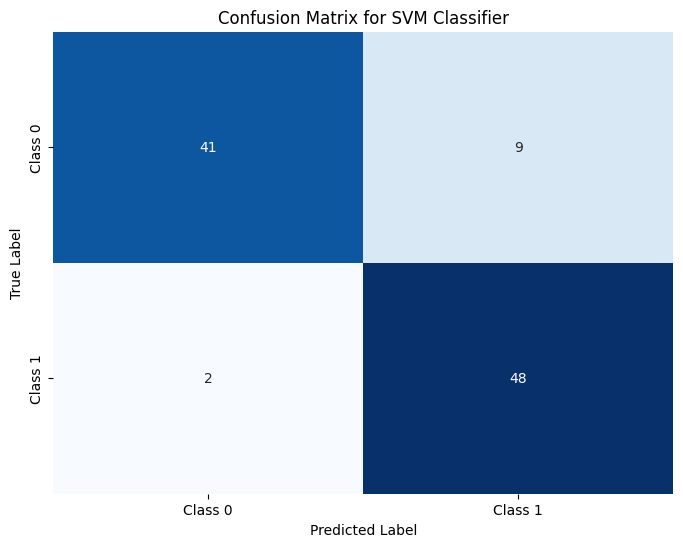

Confusion Matrix visualized successfully.


In [452]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

print("Confusion Matrix visualized successfully.")

### 44. Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE .

## Load Regression Dataset

### Subtask:
Load a suitable regression dataset (e.g., California housing dataset from `sklearn.datasets`). Display its shape and the first few entries to understand the data.


In [453]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the California housing dataset
housing = fetch_california_housing(as_frame=True)

# Extract features (X) and target (y)
X = housing.data
y = housing.target

print("California Housing Dataset loaded successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 rows of Features (X):\n", X.head())
print("\nFirst 5 rows of Target (y):\n", y.head())

California Housing Dataset loaded successfully.
Features (X) shape: (20640, 8)
Target (y) shape: (20640,)

First 5 rows of Features (X):
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

First 5 rows of Target (y):
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [454]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (16512, 8)
Testing set features shape: (4128, 8)
Training set target shape: (16512,)
Testing set target shape: (4128,)


In [455]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (16512, 8)
Scaled Testing set features shape: (4128, 8)


In [456]:
from sklearn.svm import SVR

# Initialize the SVR model with an RBF kernel
# C is the regularization parameter, epsilon is the epsilon-tube width
# gamma='scale' is a common starting point
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

# Train the SVR model on the scaled training data
svr_model.fit(X_train_scaled, y_train)

print("SVR model trained successfully with RBF kernel.")

SVR model trained successfully with RBF kernel.


In [457]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the scaled test set
y_pred_svr = svr_model.predict(X_test_scaled)

print("Predictions made on the test set.")

Predictions made on the test set.


In [458]:
mae = mean_absolute_error(y_test, y_pred_svr)
print(f"Mean Absolute Error (MAE) of the SVR model: {mae:.4f}")

Mean Absolute Error (MAE) of the SVR model: 0.3986


### 45. Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification (e.g., using `sklearn.datasets.make_classification`). Display its shape and the first few entries.


In [459]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [460]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [461]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naïve Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier on the training data
nb_classifier.fit(X_train, y_train)

print("Gaussian Naïve Bayes Classifier trained successfully.")

# Make probability predictions on the test set (needed for ROC-AUC)
y_pred_proba = nb_classifier.predict_proba(X_test)

print("Probability predictions made on the test set.")

Gaussian Naïve Bayes Classifier trained successfully.
Probability predictions made on the test set.


In [462]:
from sklearn.metrics import roc_auc_score

# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"ROC-AUC Score of the Naïve Bayes Classifier: {roc_auc:.4f}")

ROC-AUC Score of the Naïve Bayes Classifier: 0.8988


### 46. Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve .

## Generate Dataset

### Subtask:
Generate a synthetic dataset suitable for binary classification (e.g., using `sklearn.datasets.make_classification`). Display its shape and the first few entries.


In [463]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset with continuous features
X, y = make_classification(n_samples=500,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_classes=2,
                           random_state=42)

print("Synthetic dataset with continuous features generated successfully.")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 samples of features (X):\n", X[:5])
print("\nFirst 5 samples of target (y):\n", y[:5])

Synthetic dataset with continuous features generated successfully.
Features (X) shape: (500, 20)
Target (y) shape: (500,)

First 5 samples of features (X):
 [[ 1.02933892e+00 -1.21740379e+00  3.63624751e+00 -2.64532924e+00
   1.64201664e+00  3.43145975e+00 -6.30930834e-01  1.60384039e+00
  -2.25685450e+00  4.67950422e-01  1.86519604e+00 -6.35310368e+00
  -1.62202993e+00 -7.88382371e-01  2.94666426e-01 -1.17028071e+00
  -1.11408136e+00  1.59944301e+00 -2.62274274e+00  8.80834813e+00]
 [ 1.66222581e+00  1.00223617e+00 -1.33943454e+00  1.24822526e+00
  -1.21152775e+00 -2.19401418e+00  1.30944410e+00  3.43903553e-01
   1.38283814e+00  1.56025553e+00 -1.85612208e+00  3.36434794e+00
  -7.13092664e-01 -5.62818846e-01 -1.59911978e+00 -1.95160291e+00
  -1.31544131e+00 -1.18465728e+00  3.27556760e+00 -8.73869178e+00]
 [ 5.76497661e-01  2.17207938e-01 -3.47019870e+00  2.76455351e+00
   1.44720891e+00  4.03091458e+00  1.78290560e+00 -3.16862966e+00
   3.39401559e+00 -4.64767224e-01 -2.16707750e+00

In [464]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Testing set target shape: {y_test.shape}")

Training set features shape: (400, 20)
Testing set features shape: (100, 20)
Training set target shape: (400,)
Testing set target shape: (100,)


In [465]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"Scaled Training set features shape: {X_train_scaled.shape}")
print(f"Scaled Testing set features shape: {X_test_scaled.shape}")

Features scaled successfully.
Scaled Training set features shape: (400, 20)
Scaled Testing set features shape: (100, 20)


In [466]:
from sklearn.svm import SVC

# Initialize the SVM classifier (using RBF kernel as a common choice)
svm_classifier = SVC(kernel='rbf', random_state=42)

# Train the SVM classifier on the scaled training data
svm_classifier.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully on scaled data.")

SVM Classifier trained successfully on scaled data.


In [467]:
y_pred = svm_classifier.predict(X_test_scaled)

print("Predictions made on the scaled test set.")

Predictions made on the scaled test set.


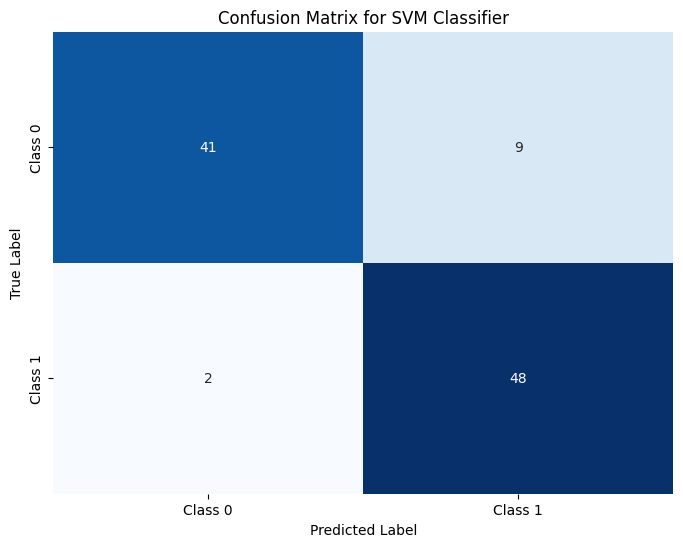

Confusion Matrix visualized successfully.


In [468]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()

print("Confusion Matrix visualized successfully.")

## Train SVM Classifier (with probability=True)

### Subtask:
Initialize and train an SVM classifier (SVC with an RBF kernel) on the scaled training data, ensuring `probability=True` is set for probability predictions.


In [469]:
from sklearn.svm import SVC

# Initialize the SVM classifier (using RBF kernel as a common choice)
# Set probability=True to enable probability estimates, which are needed for Precision-Recall curve
svm_classifier = SVC(kernel='rbf', random_state=42, probability=True)

# Train the SVM classifier on the scaled training data
svm_classifier.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully on scaled data with probability estimates enabled.")

SVM Classifier trained successfully on scaled data with probability estimates enabled.


In [470]:
y_pred_proba = svm_classifier.predict_proba(X_test_scaled)

print("Probability predictions made on the scaled test set.")

Probability predictions made on the scaled test set.
